<a href="https://colab.research.google.com/github/danieloladele7/Carbon-Aware-Benchmarking-of-LTS-Models-for-STSPF-in-Smart-Grids/blob/main/solar_forecasting_green_ai_notebook_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carbon-Aware Benchmarking of Lightweight Time-Series Models for Short-Term Solar Power Forecasting in Smart Grids

This notebook implements an end-to-end, **Colab-friendly** benchmarking pipeline for a manuscript on **short-term solar power forecasting** using the **NREL PERFORM ERCOT** dataset.

## Study scope

- **Task**: 1-hour-ahead forecasting of **BA/system-level solar power**
- **Source data**: ERCOT solar actuals from the public **ARPA-E PERFORM / NREL** dataset
- **Input resolution**: native 5-minute data
- **Modeling resolution**: resampled to **hourly mean MW**
- **Forecast horizon**: next **1 hour**
- **History window**: previous **24 hours**
- **Chronological split**:
  - Train: **Jan-Dec 2017**
  - Validation: **Jan-Apr 2018**
  - Test: **May-Dec 2018**
- **Models**:
  - Baseline 1: Persistence
  - Baseline 2: Seasonal Naive (same hour previous day)
  - Model 1: XGBoost
  - Model 2: LSTM
  - Model 3: DLinear
- **Comparison dimensions**:
  - Forecast accuracy
  - Runtime and inference latency
  - Carbon / emissions estimate with CodeCarbon

## Why this notebook is scoped this way

1. it uses a **public, credible** smart-grid dataset,
2. it runs comfortably on **Google Colab**,
3. it compares **lightweight** methods rather than large, compute-heavy architectures.

## References used for notebook design

- NREL PERFORM ERCOT documentation and public AWS registry
- CodeCarbon documentation for emissions tracking

> Practical note: CodeCarbon values are **estimates**, not laboratory-grade measurements. But they are very useful for **relative comparison** across models inside the same runtime environment.

In [3]:
# If you are running on Google Colab, uncomment and run the installation cell.
# We use --force-reinstall to fix the binary incompatibility error.

!pip install -q --no-warn-conflicts --force-reinstall \
  pandas==2.2.2 \
  numpy==1.26.4 \
  requests==2.32.4 \
  cryptography==43.0.3 \
  pydantic==2.12.3 \
  fsspec==2025.3.0 \
  s3fs h5py xgboost codecarbon torch scikit-learn matplotlib tqdm statsmodels

# IMPORTANT: Once this cell finishes running the first time
# go to 'Runtime' -> 'Restart session' before proceeding.

## 1. Imports and reproducibility

In [1]:

import os
import gc
import math
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import h5py
import s3fs

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid

from xgboost import XGBRegressor

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from codecarbon import EmissionsTracker
from scipy.stats import norm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cpu


## 2. Configuration

All key settings for easy change

In [2]:

CONFIG = {
    "project_name": "solar_forecasting_green_ai",
    "output_dir": "/content/outputs",
    "cache_dir": "./cache",
    "s3_bucket": "s3://arpa-e-perform",
    "iso": "ERCOT",
    "resource": "Solar",
    "spatial_level": "BA_level",          # BA_level ~ balancing authority / system-level aggregate
    "resample_rule": "1H",                # converting 5-minute actuals to hourly average MW
    "history_hours": 24,                  # input lookback window
    "horizon_hours": 1,                   # next-hour forecasting
    "batch_size": 128,
    "num_workers": 2,
    "lstm_epochs": 200,
    "dlinear_epochs": 200,
    "patience": 6,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "hidden_size": 64,
    "lstm_layers": 1,
    "dropout": 0.1,
    "dlinear_kernel_sizes": [7, 13],#, 25, 37],
    "dlinear_kernel_size": 7,            # Set based on the best kernel search
    "norm_target_by_train_max": True,
    "save_predictions": True,
    "run_emissions_tracking": True,
    "run_dlinear_kernel_search": False,
    "run_xgb_grid_search": False,         # make t False for fast reproducibility
}

OUTPUT_DIR = Path(CONFIG["output_dir"])
CACHE_DIR = Path(CONFIG["cache_dir"])
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CONFIG

{'project_name': 'solar_forecasting_green_ai',
 'output_dir': '/content/outputs',
 'cache_dir': './cache',
 's3_bucket': 's3://arpa-e-perform',
 'iso': 'ERCOT',
 'resource': 'Solar',
 'spatial_level': 'BA_level',
 'resample_rule': '1H',
 'history_hours': 24,
 'horizon_hours': 1,
 'batch_size': 128,
 'num_workers': 2,
 'lstm_epochs': 200,
 'dlinear_epochs': 200,
 'patience': 6,
 'learning_rate': 0.001,
 'weight_decay': 1e-05,
 'hidden_size': 64,
 'lstm_layers': 1,
 'dropout': 0.1,
 'dlinear_kernel_sizes': [7, 13],
 'dlinear_kernel_size': 7,
 'norm_target_by_train_max': True,
 'save_predictions': True,
 'run_emissions_tracking': True,
 'run_dlinear_kernel_search': False,
 'run_xgb_grid_search': False}

## 3. Helper utilities

This section contains the generic helper functions for:
- timing,
- emissions tracking,
- metric computation,
- plotting,
- file export.

In [3]:

class Timer:
    def __enter__(self):
        self.start = time.perf_counter()
        return self
    def __exit__(self, *args):
        self.end = time.perf_counter()
        self.elapsed = self.end - self.start

def start_tracker(model_name: str):
    if not CONFIG["run_emissions_tracking"]:
        return None
    tracker = EmissionsTracker(
        project_name=f"{CONFIG['project_name']}_{model_name}",
        output_dir=str(OUTPUT_DIR),
        measure_power_secs=1,
        save_to_file=True,
        log_level="error",
    )
    tracker.start()
    return tracker

def stop_tracker(tracker):
    if tracker is None:
        return np.nan
    emissions = tracker.stop()
    return emissions if emissions is not None else np.nan

def rmse(y_true, y_pred):
    return math.sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) + eps
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def regression_metrics(y_true, y_pred, norm_factor):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "sMAPE_%": smape(y_true, y_pred),
        "nMAE": mean_absolute_error(y_true, y_pred) / norm_factor,
        "nRMSE": rmse(y_true, y_pred) / norm_factor,
    }

def print_section(title):
    print("\n" + "=" * 100)
    print(title)
    print("=" * 100)

def diebold_mariano_test(target, pred1, pred2, h=1):
    """Simple DM test for forecast comparison."""
    e1 = (target - pred1)**2
    e2 = (target - pred2)**2
    d = e1 - e2
    d_mean = np.mean(d)
    d_var = np.var(d, ddof=1)
    if d_var <= 0: return 0.0, 1.0
    stat = d_mean / np.sqrt(d_var / len(d))
    p_val = 2 * (1 - norm.cdf(abs(stat)))
    return stat, p_val

def save_csv(df, filename):
    path = OUTPUT_DIR / filename
    df.to_csv(path, index=False)
    return path

def plot_series(df, title, start=None, end=None, cols=None, figsize=(14, 4), save=None):
    temp = df.copy()
    if start is not None:
        temp = temp.loc[start:]
    if end is not None:
        temp = temp.loc[:end]
    if cols is None:
        cols = temp.columns.tolist()
    temp[cols].plot(figsize=figsize)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("MW")
    if save:
      plt.savefig(OUTPUT_DIR / f'{save}.png', dpi=800, bbox_inches='tight')
    plt.show()

## 4. Data access: NREL PERFORM ERCOT solar actuals

As specified by the official documentation, the [ARPA-E PERFORM ERCOT](https://github.com/PERFORM-Forecasts/documentation) dataset:
- is stored as **HDF5**,
- is hosted on a **public AWS S3 bucket**,
- provides **2017 and 2018 actuals**,
- includes solar data at **site, zone, and system / BA levels**.

We will work with **BA-level solar actuals** and build our own next-hour forecasting benchmark from the actual historical time series.

In [4]:

fs = s3fs.S3FileSystem(anon=True)

def to_s3_uri(path_like: str) -> str:
    path_like = str(path_like)
    return path_like if path_like.startswith("s3://") else f"s3://{path_like}"

def list_s3(prefix: str):
    items = fs.ls(prefix)
    return [to_s3_uri(x) for x in items]

def find_actuals_file(year: int, resource: str = "Solar", spatial_level: str = "BA_level"):
    prefix = f"{CONFIG['s3_bucket']}/{CONFIG['iso']}/{year}/{resource}/Actuals/{spatial_level}"
    files = list_s3(prefix)
    # Prefer the standard file name first, then any fallback that contains 'actuals'
    preferred = [f for f in files if f.lower().endswith(f"{resource.lower()}_actuals_{year}.h5")]
    generic = [f for f in files if "actuals" in f.lower() and f.lower().endswith(".h5")]
    candidates = preferred + [f for f in generic if f not in preferred]
    if not candidates:
        raise FileNotFoundError(f"No actuals file found under: {prefix}")
    return candidates[0]

for yr in [2017, 2018]:
    print(yr, "->", find_actuals_file(yr))

2017 -> s3://arpa-e-perform/ERCOT/2017/Solar/Actuals/BA_level/BA_solar_actuals_2017.h5
2018 -> s3://arpa-e-perform/ERCOT/2018/Solar/Actuals/BA_level/BA_solar_actuals_2018.h5


### 4.1 Robust HDF5 reader

The public examples indicate that the actuals files contain at least:
- `meta`
- `time_index`
- `actuals`

The helper below reads the file and converts it into a tidy pandas DataFrame.

In [5]:

def sanitize_meta_dataframe(df_meta: pd.DataFrame) -> pd.DataFrame:
    new_cols = []
    for c in df_meta.columns:
        c = c.decode() if isinstance(c, bytes) else str(c)
        new_cols.append(c)
    df_meta.columns = new_cols

    for col in df_meta.columns:
        if df_meta[col].dtype == object:
            df_meta[col] = df_meta[col].apply(lambda x: x.decode() if isinstance(x, bytes) else x)
    return df_meta

def infer_column_names(df_meta: pd.DataFrame, n_cols: int):
    candidates = ["facility_name", "plant_name", "name", "site_name", "id", "gid"]
    col_source = None
    for c in candidates:
        if c in df_meta.columns:
            col_source = c
            break
    if col_source is not None and len(df_meta) == n_cols:
        vals = df_meta[col_source].astype(str).tolist()
        vals = [v if v and v != "nan" else f"series_{i}" for i, v in enumerate(vals)]
        return vals
    return [f"series_{i}" for i in range(n_cols)]

def read_actuals_h5(s3_path: str):
    with fs.open(s3_path, "rb") as fobj:
        with h5py.File(fobj, "r") as h5f:
            keys = list(h5f.keys())
            print("HDF5 keys:", keys)

            meta = pd.DataFrame(h5f["meta"][...])
            meta = sanitize_meta_dataframe(meta)

            time_index = pd.to_datetime(h5f["time_index"][...].astype(str), utc=True)
            actuals = np.asarray(h5f["actuals"][...], dtype=np.float32)

    if actuals.ndim == 1:
        df = pd.DataFrame({"solar_mw": actuals}, index=time_index)
    else:
        n_cols = actuals.shape[1]
        cols = infer_column_names(meta, n_cols)
        df = pd.DataFrame(actuals, index=time_index, columns=cols)

    return df.sort_index(), meta

solar_2017_raw, meta_2017 = read_actuals_h5(find_actuals_file(2017))
solar_2018_raw, meta_2018 = read_actuals_h5(find_actuals_file(2018))

print("2017 shape:", solar_2017_raw.shape)
print("2018 shape:", solar_2018_raw.shape)
display(meta_2017.head())
display(solar_2017_raw.head())

HDF5 keys: ['actuals', 'meta', 'time_index']
HDF5 keys: ['actuals', 'meta', 'time_index']
2017 shape: (105120, 227)
2018 shape: (105120, 227)


,site_ids,AC_capacity_MW,module_type,dc_ac_ratio,azimuth,latitude,longitude,elevation,timezone,country,state,county,urban,population,landcover,gid,reV_tech,proposed,Zone,ISO
0,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA,BA
1,Adamstown Solar,250,0,1.25,180,33.25,-97.26,220.16,-6,bUnited States,bTexas,bDenton,bNone,438,140,690482,bpv,Proposed,NORTH,ERCOT
2,Agate Solar,60,0,1.3,180,32.45,-97.18,217.84,-6,bUnited States,bTexas,bJohnson,bNone,2105,140,692563,bpv,Proposed,NORTH CENTRAL,ERCOT
3,Angelina Solar,150,0,1.4,180,31.37,-94.86,85,-6,bUnited States,bTexas,bAngelina,bNone,183,50,744853,bpv,Proposed,EAST,ERCOT
4,Angelo Solar,195,2,1.25,180,31.41,-100.58,623.72,-6,bUnited States,bTexas,bTom Green,bNone,32,30,600558,bpv,Proposed,WEST,ERCOT


,BA,690482,692563,744853,600558,690817,613149,608193,611403,493177,...,561857,679307,703772,728124,584777,697829,522426,730218,547331,605371
2017-01-01 00:00:00+00:00,0.1755,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:05:00+00:00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:10:00+00:00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:15:00+00:00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 00:20:00+00:00,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 4.2 Convert to a single BA/system-level target series

Depending on the file structure, BA-level data may already contain a single aggregate series.  
If multiple columns are present, we aggregate them into a total system-level `solar_mw`.

In [6]:

def collapse_to_target_series(df: pd.DataFrame, target_name="solar_mw"):
    out = df.copy()

    # If a clean single-column series already exists, keep it
    if out.shape[1] == 1:
        out = out.rename(columns={out.columns[0]: target_name})
    else:
        out[target_name] = out.sum(axis=1)
        out = out[[target_name]]

    # Clean invalid values
    out[target_name] = pd.to_numeric(out[target_name], errors="coerce")
    out[target_name] = out[target_name].clip(lower=0)
    out = out[~out.index.duplicated(keep="first")].sort_index()

    return out

solar_2017 = collapse_to_target_series(solar_2017_raw)
solar_2018 = collapse_to_target_series(solar_2018_raw)

solar_5min = pd.concat([solar_2017, solar_2018]).sort_index()
print("Combined 5-minute series shape:", solar_5min.shape)
display(solar_5min.head())
display(solar_5min.tail())

Combined 5-minute series shape: (210240, 1)


,solar_mw
2017-01-01 00:00:00+00:00,0.351
2017-01-01 00:05:00+00:00,0.000
2017-01-01 00:10:00+00:00,0.000
2017-01-01 00:15:00+00:00,0.000
2017-01-01 00:20:00+00:00,0.000


,solar_mw
2018-12-31 23:35:00+00:00,3661.754395
2018-12-31 23:40:00+00:00,2143.497070
2018-12-31 23:45:00+00:00,875.261047
2018-12-31 23:50:00+00:00,192.482193
2018-12-31 23:55:00+00:00,46.750355


## 5. Initial data quality checks and exploratory analysis

In [7]:

print_section("Data coverage")
print("Start:", solar_5min.index.min())
print("End  :", solar_5min.index.max())
print("Nulls:", solar_5min['solar_mw'].isna().sum())
print("Min  :", solar_5min['solar_mw'].min())
print("Max  :", solar_5min['solar_mw'].max())
print("Mean :", solar_5min['solar_mw'].mean())


Data coverage
Start: 2017-01-01 00:00:00+00:00
End  : 2018-12-31 23:55:00+00:00
Nulls: 0
Min  : 0.0
Max  : 81048.484375
Mean : 23965.742


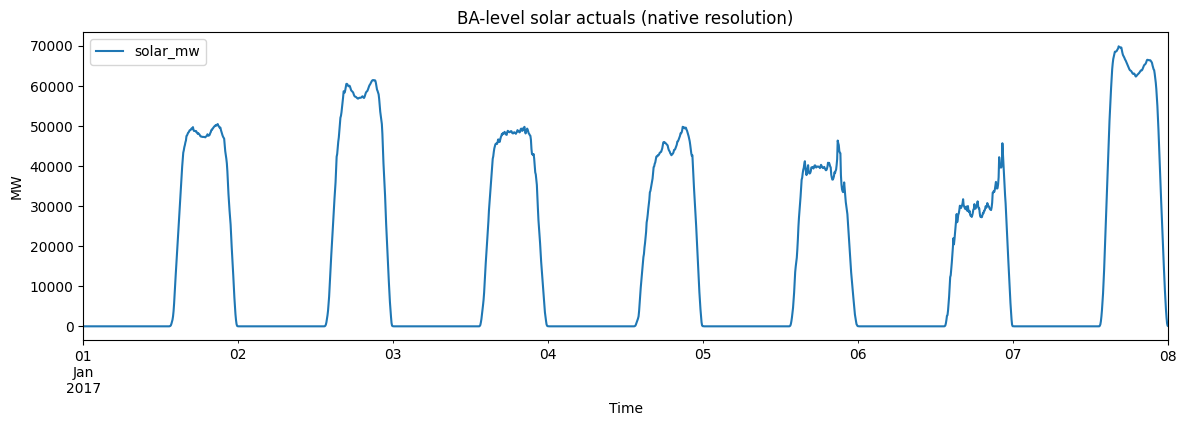

In [8]:

plot_series(
    solar_5min,
    title="BA-level solar actuals (native resolution)",
    start=solar_5min.index.min(),
    end=solar_5min.index.min() + pd.Timedelta(days=7),
    save="solar_5min_raw"
)

### 5.1 Resample to hourly mean MW

The raw series is in 5-minute resolution.  
For a lightweight forecasting study and fair runtime comparison, we resample to **hourly mean power**.

This has three advantages:
1. it reduces noise and dimensionality,
2. it makes the sequence models faster to train,
3. it is enough for a strong short-term forecasting benchmark.

In [9]:

solar_hourly = (
    solar_5min
    .resample(CONFIG["resample_rule"])
    .mean()
    .rename(columns={"solar_mw": "y"})
)

# Fill rare gaps after resampling
solar_hourly["y"] = solar_hourly["y"].interpolate(method="time").fillna(0)

print("Hourly shape:", solar_hourly.shape)
display(solar_hourly.head())
display(solar_hourly.tail())

Hourly shape: (17520, 1)


,y
2017-01-01 00:00:00+00:00,0.02925
2017-01-01 01:00:00+00:00,0.00000
2017-01-01 02:00:00+00:00,0.00000
2017-01-01 03:00:00+00:00,0.00000
2017-01-01 04:00:00+00:00,0.00000


,y
2018-12-31 19:00:00+00:00,49981.988281
2018-12-31 20:00:00+00:00,50928.261719
2018-12-31 21:00:00+00:00,50833.441406
2018-12-31 22:00:00+00:00,36418.503906
2018-12-31 23:00:00+00:00,8008.478516


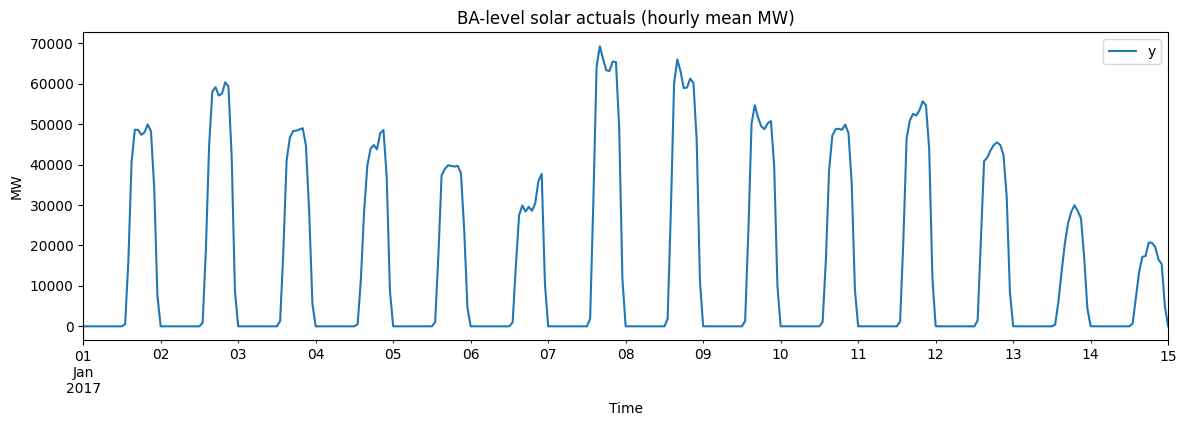

In [10]:

plot_series(
    solar_hourly,
    title="BA-level solar actuals (hourly mean MW)",
    start=solar_hourly.index.min(),
    end=solar_hourly.index.min() + pd.Timedelta(days=14),
    save="solar_hourly"
)

## 6. Forecast problem definition

We now define the supervised learning task:

- **Input**: previous 24 hours of hourly solar power
- **Target**: solar power in the next hour
- **Frequency**: hourly
- **Split**: chronological only; no random shuffling

This avoids leakage and matches real forecasting practice.

In [11]:

TRAIN_END = pd.Timestamp("2017-12-31 23:00:00", tz="UTC")
VAL_END = pd.Timestamp("2018-04-30 23:00:00", tz="UTC")

train_df = solar_hourly.loc[:TRAIN_END].copy()
val_df = solar_hourly.loc[TRAIN_END + pd.Timedelta(hours=1):VAL_END].copy()
test_df = solar_hourly.loc[VAL_END + pd.Timedelta(hours=1):].copy()

print("Train:", train_df.shape, train_df.index.min(), "->", train_df.index.max())
print("Val  :", val_df.shape, val_df.index.min(), "->", val_df.index.max())
print("Test :", test_df.shape, test_df.index.min(), "->", test_df.index.max())

Train: (8760, 1) 2017-01-01 00:00:00+00:00 -> 2017-12-31 23:00:00+00:00
Val  : (2880, 1) 2018-01-01 00:00:00+00:00 -> 2018-04-30 23:00:00+00:00
Test : (5880, 1) 2018-05-01 00:00:00+00:00 -> 2018-12-31 23:00:00+00:00


## 7. Feature engineering

For the tree-based model we create:
- lag features from the previous 24 hours,
- rolling means and standard deviations,
- calendar features:
  - hour of day (sine/cosine),
  - day of week,
  - month,
  - day of year (sine/cosine),
  - weekend flag.

For the neural models we use the **raw history window** directly.  
***Which mirrors the common practice***: tree models rely on engineered tabular features, while sequence models learn their own temporal representation from the lag window.

In [12]:

def add_calendar_features(df: pd.DataFrame):
    out = df.copy()
    idx = out.index

    out["hour"] = idx.hour
    out["dayofweek"] = idx.dayofweek
    out["month"] = idx.month
    out["dayofyear"] = idx.dayofyear
    out["is_weekend"] = (idx.dayofweek >= 5).astype(int)

    out["hour_sin"] = np.sin(2 * np.pi * out["hour"] / 24.0)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour"] / 24.0)
    out["doy_sin"] = np.sin(2 * np.pi * out["dayofyear"] / 365.25)
    out["doy_cos"] = np.cos(2 * np.pi * out["dayofyear"] / 365.25)
    return out

def make_tabular_features(df: pd.DataFrame, history=24, horizon=1):
    out = df.copy()

    for lag in range(1, history + 1):
        out[f"lag_{lag}"] = out["y"].shift(lag)

    for w in [3, 6, 12, 24]:
        out[f"roll_mean_{w}"] = out["y"].shift(1).rolling(window=w).mean()
        out[f"roll_std_{w}"] = out["y"].shift(1).rolling(window=w).std()

    out = add_calendar_features(out)
    out["target"] = out["y"].shift(-horizon)
    out = out.dropna()
    return out

tab_all = make_tabular_features(solar_hourly, history=CONFIG["history_hours"], horizon=CONFIG["horizon_hours"])

tab_train = tab_all.loc[train_df.index.min():train_df.index.max()].copy()
tab_val = tab_all.loc[val_df.index.min():val_df.index.max()].copy()
tab_test = tab_all.loc[test_df.index.min():test_df.index.max()].copy()

feature_cols = [c for c in tab_all.columns if c not in ["y", "target"]]
X_train, y_train = tab_train[feature_cols], tab_train["target"]
X_val, y_val = tab_val[feature_cols], tab_val["target"]
X_test, y_test = tab_test[feature_cols], tab_test["target"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)

display(tab_train.head())

X_train: (8736, 41) y_train: (8736,)
X_val  : (2880, 41) y_val  : (2880,)
X_test : (5879, 41) y_test : (5879,)


,y,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,...,hour,dayofweek,month,dayofyear,is_weekend,hour_sin,hour_cos,doy_sin,doy_cos,target
2017-01-02 00:00:00+00:00,0.057767,7654.893066,34282.652344,48218.707031,49958.894531,47981.292969,47389.550781,48633.015625,48641.902344,40732.707031,...,0,0,1,2,0,0.000000,1.000000,0.034398,0.999408,0.0
2017-01-02 01:00:00+00:00,0.000000,0.057767,7654.893066,34282.652344,48218.707031,49958.894531,47981.292969,47389.550781,48633.015625,48641.902344,...,1,0,1,2,0,0.258819,0.965926,0.034398,0.999408,0.0
2017-01-02 02:00:00+00:00,0.000000,0.000000,0.057767,7654.893066,34282.652344,48218.707031,49958.894531,47981.292969,47389.550781,48633.015625,...,2,0,1,2,0,0.500000,0.866025,0.034398,0.999408,0.0
2017-01-02 03:00:00+00:00,0.000000,0.000000,0.000000,0.057767,7654.893066,34282.652344,48218.707031,49958.894531,47981.292969,47389.550781,...,3,0,1,2,0,0.707107,0.707107,0.034398,0.999408,0.0
2017-01-02 04:00:00+00:00,0.000000,0.000000,0.000000,0.000000,0.057767,7654.893066,34282.652344,48218.707031,49958.894531,47981.292969,...,4,0,1,2,0,0.866025,0.500000,0.034398,0.999408,0.0


## 8. Baselines

We include two strong and interpretable baselines:

1. **Persistence**  
   Predict next hour = current hour

2. **Seasonal Naive**  
   Predict next hour = same hour on the previous day

These are important because a forecasting model should not be considered useful unless it clearly beats simple operational baselines.

In [13]:

def persistence_forecast(series: pd.Series):
    return series.shift(1)

def seasonal_naive_forecast(series: pd.Series, season=24):
    return series.shift(season)

baseline_df = solar_hourly.copy()
baseline_df["persistence"] = persistence_forecast(baseline_df["y"])
baseline_df["seasonal_naive"] = seasonal_naive_forecast(baseline_df["y"], season=24)
baseline_df["target"] = baseline_df["y"].shift(-CONFIG["horizon_hours"])

baseline_eval = baseline_df.dropna().copy()
baseline_test = baseline_eval.loc[test_df.index.min():test_df.index.max()].copy()

norm_factor = train_df["y"].max() if CONFIG["norm_target_by_train_max"] else 1.0
print("Normalization factor:", norm_factor)

baseline_results = []
for name in ["persistence", "seasonal_naive"]:
    m = regression_metrics(baseline_test["target"], baseline_test[name], norm_factor)
    m["model"] = name
    m["train_time_sec"] = 0.0
    m["inference_time_ms_per_sample"] = 0.0
    m["emissions_kg_co2eq"] = 0.0
    baseline_results.append(m)

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)

Normalization factor: 81017.2421875


,MAE,RMSE,sMAPE_%,nMAE,nRMSE,model,train_time_sec,inference_time_ms_per_sample,emissions_kg_co2eq
0,10167.041016,18173.730492,60.885018,0.125492,0.224319,persistence,0.0,0.0,0.0
1,7272.214844,12577.025403,45.303905,0.089761,0.155239,seasonal_naive,0.0,0.0,0.0


## 9. XGBoost model

This model uses the tabular lag and calendar features defined above.

Why XGBoost here?
- fast to train,
- strong baseline for structured time-series features,
- usually very competitive in short-horizon forecasting with engineered lags.

In [14]:

def train_xgb(X_train, y_train, X_val, y_val):
    params = { # adjusted to the best params from the grid search
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_alpha": 0.0,
        "reg_lambda": 1.5,
        "random_state": SEED,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "n_jobs": -1,
    }
    if CONFIG["run_xgb_grid_search"]:
      grid = {
          "n_estimators": [300, 400, 500],
          "max_depth": [4, 6, 8],
          "learning_rate": [0.03, 0.05, 0.1],
          "subsample": [0.9],
          "colsample_bytree": [0.9],
          "reg_alpha": [0.0, 0.1],
          "reg_lambda": [1.0, 1.5],
      }
      best_model = None
      best_rmse = float("inf")
      best_params = None
      for combo in tqdm(list(ParameterGrid(grid)), desc="XGB grid search"):
          p = params.copy()
          p.update(combo)
          model = XGBRegressor(**p)
          model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
          pred = model.predict(X_val)
          score = rmse(y_val, pred)
          if score < best_rmse:
              best_rmse = score
              best_model = model
              best_params = combo
      print(f"Best XGBoost params: {best_params} with val RMSE = {best_rmse:.4f}")
      # Store best_params for later logging (e.g., save to a file)
      return best_model, best_params
    else:
      model = XGBRegressor(**params)
      model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
      return model, params

print_section("Training XGBoost")
tracker = start_tracker("xgboost")
with Timer() as t:
    xgb_model, xgb_best_params = train_xgb(X_train, y_train, X_val, y_val)

# Print best_params
print("XGBoost best hyperparameters:", xgb_best_params)

xgb_emissions = stop_tracker(tracker)
xgb_train_time = t.elapsed

with Timer() as infer_t:
    xgb_pred = xgb_model.predict(X_test)
xgb_infer_ms = (infer_t.elapsed / len(X_test)) * 1000

xgb_metrics = regression_metrics(y_test, xgb_pred, norm_factor)
xgb_metrics.update({
    "model": "xgboost",
    "train_time_sec": xgb_train_time,
    "inference_time_ms_per_sample": xgb_infer_ms,
    "emissions_kg_co2eq": xgb_emissions,
})

xgb_results_df = pd.DataFrame([xgb_metrics])
display(xgb_results_df)

# Save XGBoost model
xgb_model_path = OUTPUT_DIR / "xgboost_model.json"
xgb_model.save_model(xgb_model_path)
print(f"XGBoost model saved to {xgb_model_path}")

# Optionally save the best hyperparameters (if you captured them)
if xgb_best_params:
    import json
    with open(OUTPUT_DIR / "xgboost_best_params.json", "w") as f:
        json.dump(xgb_best_params, f, indent=4)

[codecarbon WARNING @ 07:38:49] Multiple instances of codecarbon are allowed to run at the same time.



Training XGBoost
XGBoost best hyperparameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.05, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_alpha': 0.0, 'reg_lambda': 1.5, 'random_state': 42, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_jobs': -1}


,MAE,RMSE,sMAPE_%,nMAE,nRMSE,model,train_time_sec,inference_time_ms_per_sample,emissions_kg_co2eq
0,2012.453857,3977.17362,97.957456,0.02484,0.04909,xgboost,4.442269,0.007932,0.000019


XGBoost model saved to /content/outputs/xgboost_model.json


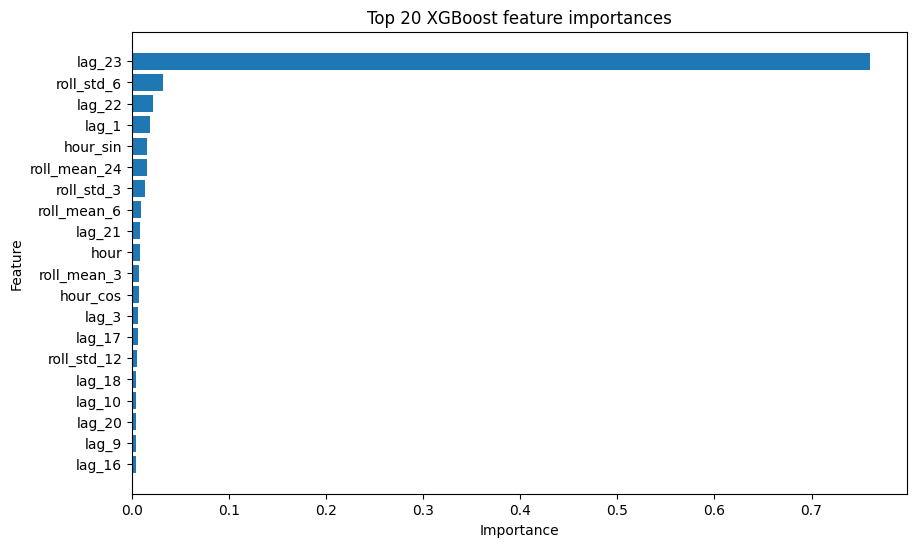

,feature,importance
22,lag_23,0.760241
27,roll_std_6,0.031981
21,lag_22,0.022241
0,lag_1,0.018745
37,hour_sin,0.015398
30,roll_mean_24,0.015114
25,roll_std_3,0.013822
26,roll_mean_6,0.009691
20,lag_21,0.008836
32,hour,0.008586


PosixPath('/content/outputs/xgb_feature_importance.csv')

In [15]:

xgb_feature_importance = (
    pd.DataFrame({
        "feature": feature_cols,
        "importance": xgb_model.feature_importances_
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

plt.figure(figsize=(10, 6))
plt.barh(xgb_feature_importance["feature"][::-1], xgb_feature_importance["importance"][::-1])
plt.title("Top 20 XGBoost feature importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig(OUTPUT_DIR / 'xgb_feature_importance.png', dpi=800, bbox_inches='tight')
plt.show()

display(xgb_feature_importance)
save_csv(xgb_feature_importance, OUTPUT_DIR / 'xgb_feature_importance.csv')


## 10. Sequence dataset for LSTM and DLinear

The neural models use a pure sequence formulation:
- input shape: `[batch, history_window, 1]`
- target shape: `[batch, horizon]`

We scale the target series using **training statistics only**.

In [16]:

class TimeSeriesWindowDataset(Dataset):
    def __init__(self, values, history, horizon):
        self.values = np.asarray(values, dtype=np.float32)
        self.history = history
        self.horizon = horizon

    def __len__(self):
        return len(self.values) - self.history - self.horizon + 1

    def __getitem__(self, idx):
        x = self.values[idx: idx + self.history]
        y = self.values[idx + self.history: idx + self.history + self.horizon]
        x = torch.tensor(x).unsqueeze(-1)  # [history, 1]
        y = torch.tensor(y)                # [horizon]
        return x, y

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[["y"]]).squeeze()
val_scaled = scaler.transform(val_df[["y"]]).squeeze()
test_scaled = scaler.transform(test_df[["y"]]).squeeze()

train_ds = TimeSeriesWindowDataset(train_scaled, CONFIG["history_hours"], CONFIG["horizon_hours"])
val_ds = TimeSeriesWindowDataset(val_scaled, CONFIG["history_hours"], CONFIG["horizon_hours"])
test_ds = TimeSeriesWindowDataset(test_scaled, CONFIG["history_hours"], CONFIG["horizon_hours"])

train_loader = DataLoader(train_ds, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"])
val_loader = DataLoader(val_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])
test_loader = DataLoader(test_ds, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"])

print("Train dataset length:", len(train_ds))
print("Val dataset length  :", len(val_ds))
print("Test dataset length :", len(test_ds))

import joblib
scaler_path = OUTPUT_DIR / "scaler_seq.pkl"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

Train dataset length: 8736
Val dataset length  : 2856
Test dataset length : 5856
Scaler saved to /content/outputs/scaler_seq.pkl


## 11. LSTM and DLinear Model definitions

In [17]:

class LSTMRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.1, horizon=1):
        super().__init__()
        effective_dropout = dropout if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=effective_dropout,
            batch_first=True,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.fc(out)
        return out


class MovingAverage(nn.Module):
    def __init__(self, kernel_size, stride=1):
        super().__init__()
        self.kernel_size = kernel_size
        self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=stride, padding=0)

    def forward(self, x):
        # x: [B, L, C]
        front = x[:, 0:1, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        end = x[:, -1:, :].repeat(1, (self.kernel_size - 1) // 2, 1)
        x = torch.cat([front, x, end], dim=1)
        x = x.permute(0, 2, 1)  # [B, C, L]
        x = self.avg(x)
        x = x.permute(0, 2, 1)  # [B, L, C]
        return x


class SeriesDecomp(nn.Module):
    def __init__(self, kernel_size):
        super().__init__()
        self.moving_avg = MovingAverage(kernel_size, stride=1)

    def forward(self, x):
        trend = self.moving_avg(x)
        seasonal = x - trend
        return seasonal, trend


class DLinear(nn.Module):
    def __init__(self, seq_len, pred_len=1, channels=1, kernel_size=25):
        super().__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.channels = channels
        self.decomp = SeriesDecomp(kernel_size)
        self.linear_seasonal = nn.Linear(seq_len, pred_len)
        self.linear_trend = nn.Linear(seq_len, pred_len)

    def forward(self, x):
        # x: [B, L, C]
        seasonal_init, trend_init = self.decomp(x)
        seasonal_init = seasonal_init.permute(0, 2, 1)  # [B, C, L]
        trend_init = trend_init.permute(0, 2, 1)        # [B, C, L]
        seasonal_out = self.linear_seasonal(seasonal_init)
        trend_out = self.linear_trend(trend_init)
        out = seasonal_out + trend_out                   # [B, C, pred_len]
        out = out.permute(0, 2, 1).squeeze(-1)           # [B, pred_len]
        return out

def train_dlinear_with_kernel_search(train_loader, val_loader, candidate_kernels):
    best_val_loss = float("inf")
    best_kernel = None
    best_model_state = None
    best_history = None
    best_train_time = None
    best_emissions = None

    for kernel in candidate_kernels:
        print(f"  Trying kernel_size = {kernel}")
        model = DLinear(
            seq_len=CONFIG["history_hours"],
            pred_len=CONFIG["horizon_hours"],
            channels=1,
            kernel_size=kernel
        ).to(DEVICE)

        # Train this kernel version
        trained_model, history, train_time, emissions = fit_torch_model(
            model_name=f"dlinear_k{kernel}",
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=CONFIG["dlinear_epochs"],
            lr=CONFIG["learning_rate"],
            weight_decay=CONFIG["weight_decay"],
            patience=CONFIG["patience"],
        )

        # Evaluate on validation set after training
        val_loss, _, _ = run_epoch(trained_model, val_loader, nn.MSELoss(), optimizer=None)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_kernel = kernel
            best_model_state = {k: v.cpu().clone() for k, v in trained_model.state_dict().items()}
            best_history = history
            best_train_time = train_time
            best_emissions = emissions

    # Recreate the best model and load the saved state
    best_model = DLinear(
        seq_len=CONFIG["history_hours"],
        pred_len=CONFIG["horizon_hours"],
        channels=1,
        kernel_size=best_kernel
    ).to(DEVICE)
    best_model.load_state_dict(best_model_state)

    print(f"  Best kernel_size = {best_kernel} with val_loss = {best_val_loss:.6f}")
    return best_model, best_history, best_train_time, best_emissions, best_kernel

## 12. Training and evaluation helpers for neural models

In [18]:

def inverse_scale(arr_2d):
    return scaler.inverse_transform(arr_2d.reshape(-1, 1)).reshape(arr_2d.shape)

def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    preds_all, targets_all = [], []

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        with torch.set_grad_enabled(is_train):
            preds = model(xb)
            loss = criterion(preds, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds_all.append(preds.detach().cpu().numpy())
        targets_all.append(yb.detach().cpu().numpy())

    preds_all = np.vstack(preds_all)
    targets_all = np.vstack(targets_all)
    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, preds_all, targets_all

def fit_torch_model(model_name, model, train_loader, val_loader, epochs, lr, weight_decay, patience):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state = None
    best_val_loss = float("inf")
    patience_counter = 0
    history = []

    tracker = start_tracker(model_name)
    with Timer() as timer:
        for epoch in range(1, epochs + 1):
            train_loss, _, _ = run_epoch(model, train_loader, criterion, optimizer)
            val_loss, _, _ = run_epoch(model, val_loader, criterion, optimizer=None)

            history.append({
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss
            })

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1

            print(f"{model_name} | epoch {epoch:02d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

            if patience_counter >= patience:
                print(f"Early stopping triggered for {model_name}.")
                break

    emissions = stop_tracker(tracker)

    model.load_state_dict(best_state)
    train_time = timer.elapsed
    history_df = pd.DataFrame(history)
    return model, history_df, train_time, emissions

def predict_torch_model(model, loader):
    criterion = nn.MSELoss()
    with Timer() as infer_timer:
        _, preds_scaled, targets_scaled = run_epoch(model, loader, criterion, optimizer=None)
    infer_ms = (infer_timer.elapsed / len(loader.dataset)) * 1000

    preds = inverse_scale(preds_scaled).reshape(-1)
    targets = inverse_scale(targets_scaled).reshape(-1)
    return preds, targets, infer_ms

## 13. Train the LSTM

In [19]:

print_section("Training LSTM")

lstm_model = LSTMRegressor(
    input_size=1,
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["lstm_layers"],
    dropout=CONFIG["dropout"],
    horizon=CONFIG["horizon_hours"]
).to(DEVICE)

lstm_model, lstm_history, lstm_train_time, lstm_emissions = fit_torch_model(
    model_name="lstm",
    model=lstm_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CONFIG["lstm_epochs"],
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    patience=CONFIG["patience"],
)

lstm_pred, lstm_true, lstm_infer_ms = predict_torch_model(lstm_model, test_loader)

lstm_metrics = regression_metrics(lstm_true, lstm_pred, norm_factor)
lstm_metrics.update({
    "model": "lstm",
    "train_time_sec": lstm_train_time,
    "inference_time_ms_per_sample": lstm_infer_ms,
    "emissions_kg_co2eq": lstm_emissions,
})

lstm_results_df = pd.DataFrame([lstm_metrics])

# Save LSTM state dict
lstm_state_path = OUTPUT_DIR / "lstm_model.pt"
torch.save(lstm_model.state_dict(), lstm_state_path)
print(f"LSTM model saved to {lstm_state_path}")

# Save LSTM hyperparameters (for reconstruction)
lstm_hparams = {
    "input_size": 1,
    "hidden_size": CONFIG["hidden_size"],
    "num_layers": CONFIG["lstm_layers"],
    "dropout": CONFIG["dropout"],
    "horizon": CONFIG["horizon_hours"],
}
import json
with open(OUTPUT_DIR / "lstm_hparams.json", "w") as f:
    json.dump(lstm_hparams, f, indent=4)

display(lstm_results_df)
save_csv(lstm_results_df, OUTPUT_DIR / 'lstm_results.csv')


Training LSTM
lstm | epoch 01 | train_loss=0.516857 | val_loss=0.145568
lstm | epoch 02 | train_loss=0.113194 | val_loss=0.105074
lstm | epoch 03 | train_loss=0.083763 | val_loss=0.081736
lstm | epoch 04 | train_loss=0.062906 | val_loss=0.068124
lstm | epoch 05 | train_loss=0.054902 | val_loss=0.061354
lstm | epoch 06 | train_loss=0.049879 | val_loss=0.060541
lstm | epoch 07 | train_loss=0.045812 | val_loss=0.050728
lstm | epoch 08 | train_loss=0.041463 | val_loss=0.044852
lstm | epoch 09 | train_loss=0.038521 | val_loss=0.042660
lstm | epoch 10 | train_loss=0.036768 | val_loss=0.038294
lstm | epoch 11 | train_loss=0.032250 | val_loss=0.034904
lstm | epoch 12 | train_loss=0.030221 | val_loss=0.031326
lstm | epoch 13 | train_loss=0.029747 | val_loss=0.032419
lstm | epoch 14 | train_loss=0.028214 | val_loss=0.031064
lstm | epoch 15 | train_loss=0.027317 | val_loss=0.028782
lstm | epoch 16 | train_loss=0.026764 | val_loss=0.026768
lstm | epoch 17 | train_loss=0.024710 | val_loss=0.026236

,MAE,RMSE,sMAPE_%,nMAE,nRMSE,model,train_time_sec,inference_time_ms_per_sample,emissions_kg_co2eq
0,1230.019165,2388.726962,96.264821,0.015182,0.029484,lstm,207.734449,0.123141,0.000865


PosixPath('/content/outputs/lstm_results.csv')

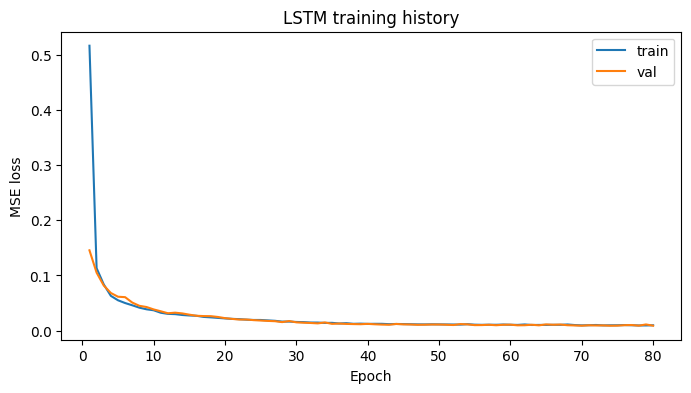

,epoch,train_loss,val_loss
75,76,0.009941,0.009691
76,77,0.009587,0.009982
77,78,0.009198,0.008826
78,79,0.009216,0.011018
79,80,0.009502,0.008790


PosixPath('/content/outputs/lstm_history.csv')

In [20]:

plt.figure(figsize=(8, 4))
plt.plot(lstm_history["epoch"], lstm_history["train_loss"], label="train")
plt.plot(lstm_history["epoch"], lstm_history["val_loss"], label="val")
plt.title("LSTM training history")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.savefig(OUTPUT_DIR / 'LSTM_training_history.png', dpi=800, bbox_inches='tight')
plt.show()

display(lstm_history.tail())
save_csv(lstm_history, OUTPUT_DIR / 'lstm_history.csv')


## 14. Train the DLinear model

In [21]:

print_section("Training DLinear")

if CONFIG.get("run_dlinear_kernel_search", False):
    # Perform kernel search – returns a fully trained best model
    dlinear_model, dlinear_history, dlinear_train_time, dlinear_emissions, best_kernel = \
        train_dlinear_with_kernel_search(
            train_loader, val_loader, CONFIG["dlinear_kernel_sizes"]
        )
    CONFIG["dlinear_best_kernel"] = best_kernel
    print(f"Selected kernel size: {best_kernel}")
else:
    # Use fixed kernel size
    dlinear_model = DLinear(
        seq_len=CONFIG["history_hours"],
        pred_len=CONFIG["horizon_hours"],
        channels=1,
        kernel_size=CONFIG["dlinear_kernel_size"]
    ).to(DEVICE)

# Train the fixed‑kernel model
dlinear_model, dlinear_history, dlinear_train_time, dlinear_emissions = fit_torch_model(
    model_name="dlinear",
    model=dlinear_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CONFIG["dlinear_epochs"],
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"],
    patience=CONFIG["patience"],
)

# --- Test evaluation (common for both branches) ---
dlinear_pred, dlinear_true, dlinear_infer_ms = predict_torch_model(dlinear_model, test_loader)

dlinear_metrics = regression_metrics(dlinear_true, dlinear_pred, norm_factor)
dlinear_metrics.update({
    "model": "dlinear",
    "train_time_sec": dlinear_train_time,
    "inference_time_ms_per_sample": dlinear_infer_ms,
    "emissions_kg_co2eq": dlinear_emissions,
})

dlinear_results_df = pd.DataFrame([dlinear_metrics])

# Save DLinear state dict
dlinear_state_path = OUTPUT_DIR / "dlinear_model.pt"
torch.save(dlinear_model.state_dict(), dlinear_state_path)
print(f"DLinear model saved to {dlinear_state_path}")

# Save DLinear hyperparameters
dlinear_hparams = {
    "seq_len": CONFIG["history_hours"],
    "pred_len": CONFIG["horizon_hours"],
    "channels": 1,
    "kernel_size": CONFIG.get("dlinear_best_kernel", CONFIG["dlinear_kernel_size"]),
}
import json
with open(OUTPUT_DIR / "dlinear_hparams.json", "w") as f:
    json.dump(dlinear_hparams, f, indent=4)


display(dlinear_results_df)
save_csv(dlinear_results_df, OUTPUT_DIR / 'dlinear_results.csv')


Training DLinear
dlinear | epoch 01 | train_loss=0.983241 | val_loss=0.459650
dlinear | epoch 02 | train_loss=0.341447 | val_loss=0.242817
dlinear | epoch 03 | train_loss=0.192066 | val_loss=0.159009
dlinear | epoch 04 | train_loss=0.124033 | val_loss=0.113647
dlinear | epoch 05 | train_loss=0.087343 | val_loss=0.088174
dlinear | epoch 06 | train_loss=0.066920 | val_loss=0.073691
dlinear | epoch 07 | train_loss=0.055225 | val_loss=0.065465
dlinear | epoch 08 | train_loss=0.048266 | val_loss=0.060416
dlinear | epoch 09 | train_loss=0.043981 | val_loss=0.057194
dlinear | epoch 10 | train_loss=0.041219 | val_loss=0.055029
dlinear | epoch 11 | train_loss=0.039225 | val_loss=0.053467
dlinear | epoch 12 | train_loss=0.037702 | val_loss=0.052098
dlinear | epoch 13 | train_loss=0.036489 | val_loss=0.050955
dlinear | epoch 14 | train_loss=0.035450 | val_loss=0.049989
dlinear | epoch 15 | train_loss=0.034567 | val_loss=0.048843
dlinear | epoch 16 | train_loss=0.033731 | val_loss=0.047920
dlinea

,MAE,RMSE,sMAPE_%,nMAE,nRMSE,model,train_time_sec,inference_time_ms_per_sample,emissions_kg_co2eq
0,2385.683838,3629.178144,101.260841,0.029447,0.044795,dlinear,93.037787,0.064471,0.000387


PosixPath('/content/outputs/dlinear_results.csv')

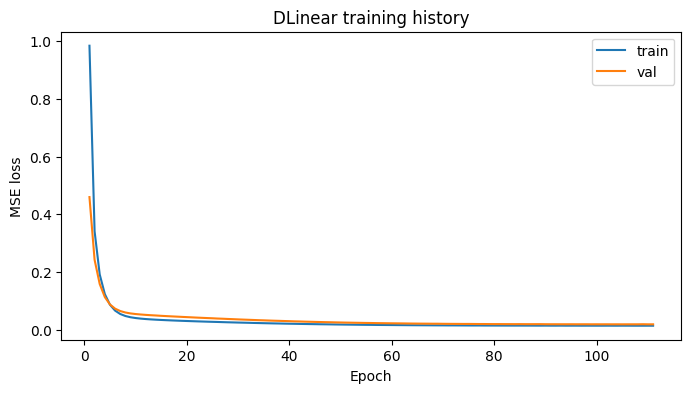

,epoch,train_loss,val_loss
106,107,0.014689,0.019527
107,108,0.014634,0.019526
108,109,0.014649,0.019785
109,110,0.014683,0.019469
110,111,0.014622,0.019493


PosixPath('/content/outputs/dlinear_history.csv')

In [22]:

plt.figure(figsize=(8, 4))
plt.plot(dlinear_history["epoch"], dlinear_history["train_loss"], label="train")
plt.plot(dlinear_history["epoch"], dlinear_history["val_loss"], label="val")
plt.title("DLinear training history")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.legend()
plt.savefig(OUTPUT_DIR / 'DLinear_training_history.png', dpi=800, bbox_inches='tight')
plt.show()

display(dlinear_history.tail())
save_csv(dlinear_history, OUTPUT_DIR / 'dlinear_history.csv')

## 15. Align neural-model targets with the test index

Because windowed sequence datasets discard the first `history_hours` timestamps of each split, we rebuild a common timestamp index for all model predictions.

In [23]:

test_index_seq = test_df.index[CONFIG["history_hours"] : CONFIG["history_hours"] + len(lstm_true)]

predictions_df = pd.DataFrame({
    "timestamp": test_index_seq,
    "actual": lstm_true,
    "lstm": lstm_pred,
    "dlinear": dlinear_pred,
}).set_index("timestamp")

# XGBoost predictions already align with tabular test index
xgb_pred_df = pd.DataFrame({
    "actual": y_test.values,
    "xgboost": xgb_pred
}, index=y_test.index)

# Baseline predictions also have their own index
baseline_pred_df = baseline_test[["target", "persistence", "seasonal_naive"]].rename(columns={"target": "actual"})

display(predictions_df.head())
save_csv(predictions_df, OUTPUT_DIR / 'lstm_dlinear_predictions.csv')

display(xgb_pred_df.head())
save_csv(xgb_pred_df, OUTPUT_DIR / 'xgb_predictions.csv')

display(baseline_pred_df.head())
save_csv(baseline_pred_df, OUTPUT_DIR / 'baseline_predictions.csv')

,actual,lstm,dlinear
timestamp,,,
2018-05-02 00:00:00+00:00,14059.629883,14443.683594,17186.632812
2018-05-02 01:00:00+00:00,965.169922,2797.935547,1012.492188
2018-05-02 02:00:00+00:00,0.000000,98.880859,-1174.585938
2018-05-02 03:00:00+00:00,0.000000,-81.156250,1274.867188
2018-05-02 04:00:00+00:00,0.000000,-58.630859,-1098.626953


,actual,xgboost
2018-05-01 00:00:00+00:00,1011.442444,860.278625
2018-05-01 01:00:00+00:00,0.000000,307.916534
2018-05-01 02:00:00+00:00,0.000000,239.147705
2018-05-01 03:00:00+00:00,0.000000,324.356201
2018-05-01 04:00:00+00:00,0.000000,256.481079


,actual,persistence,seasonal_naive
2018-05-01 00:00:00+00:00,1011.442444,32689.962891,14866.628906
2018-05-01 01:00:00+00:00,0.000000,15980.324219,582.528259
2018-05-01 02:00:00+00:00,0.000000,1011.442444,0.000000
2018-05-01 03:00:00+00:00,0.000000,0.000000,0.000000
2018-05-01 04:00:00+00:00,0.000000,0.000000,0.000000


PosixPath('/content/outputs/baseline_predictions.csv')

## 16. Unified evaluation table

To compare all models fairly, we evaluate each method on its natural aligned test target.

In a manuscript, you can note that:
- all methods use the same train/validation/test periods,
- the baselines and XGBoost operate on tabular alignment,
- LSTM and DLinear operate on sequence alignment,
- the differences in index alignment are only due to the required history window.

In [24]:

all_results_df = pd.concat(
    [
        baseline_results_df,
        xgb_results_df,
        lstm_results_df,
        dlinear_results_df
    ],
    ignore_index=True
)

metric_order = [
    "model",
    "MAE",
    "RMSE",
    "sMAPE_%",
    "nMAE",
    "nRMSE",
    "train_time_sec",
    "inference_time_ms_per_sample",
    "emissions_kg_co2eq",
]

all_results_df = all_results_df[metric_order].sort_values("RMSE").reset_index(drop=True)
display(all_results_df)
save_csv(all_results_df, OUTPUT_DIR / 'all_results.csv')

,model,MAE,RMSE,sMAPE_%,nMAE,nRMSE,train_time_sec,inference_time_ms_per_sample,emissions_kg_co2eq
0,lstm,1230.019165,2388.726962,96.264821,0.015182,0.029484,207.734449,0.123141,0.000865
1,dlinear,2385.683838,3629.178144,101.260841,0.029447,0.044795,93.037787,0.064471,0.000387
2,xgboost,2012.453857,3977.173620,97.957456,0.024840,0.049090,4.442269,0.007932,0.000019
3,seasonal_naive,7272.214844,12577.025403,45.303905,0.089761,0.155239,0.000000,0.000000,0.000000
4,persistence,10167.041016,18173.730492,60.885018,0.125492,0.224319,0.000000,0.000000,0.000000


PosixPath('/content/outputs/all_results.csv')

## 17. Plot actual vs predicted values

We visualize a manageable time window from the test set.  
This is especially useful for the manuscript figures.

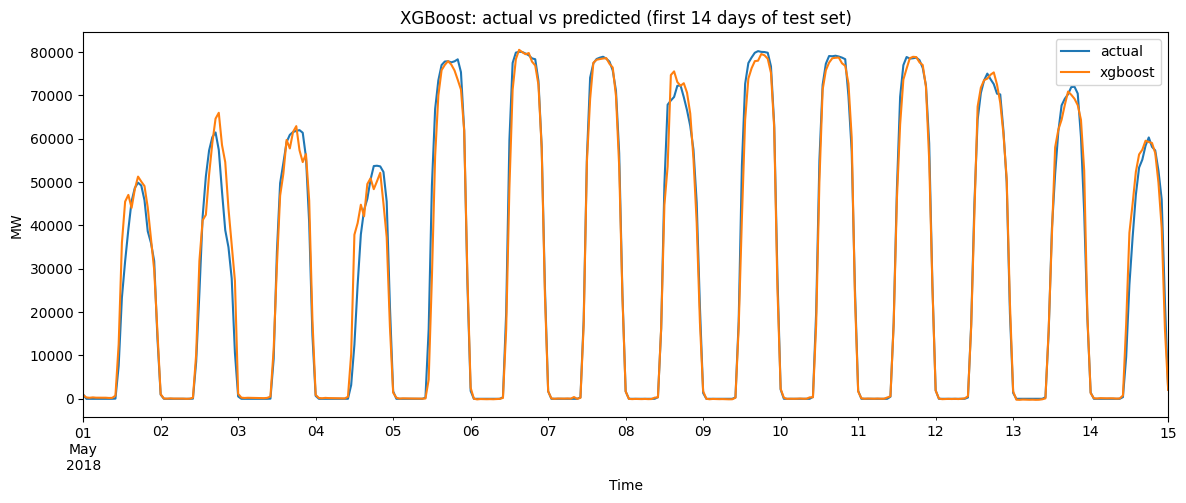

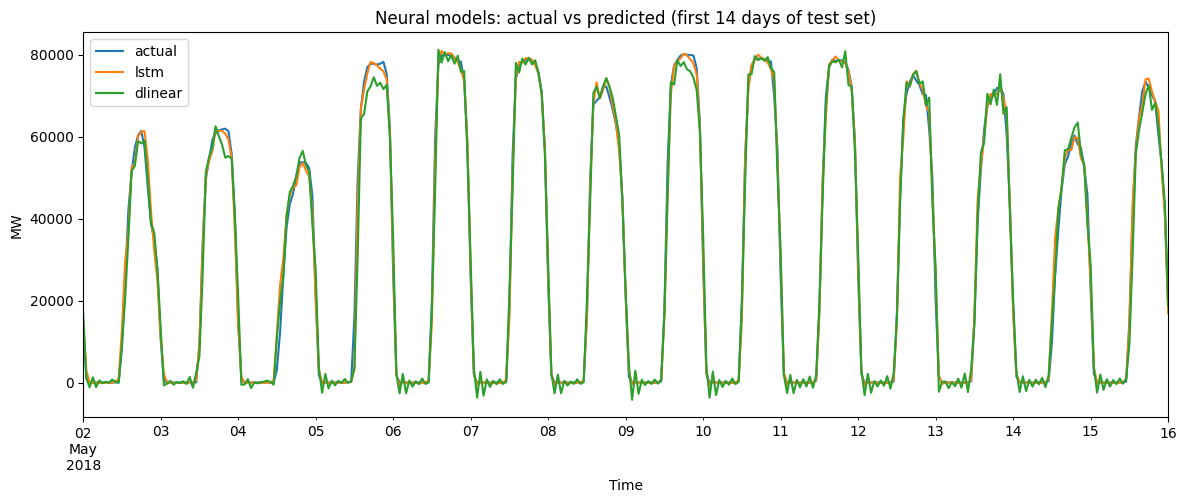

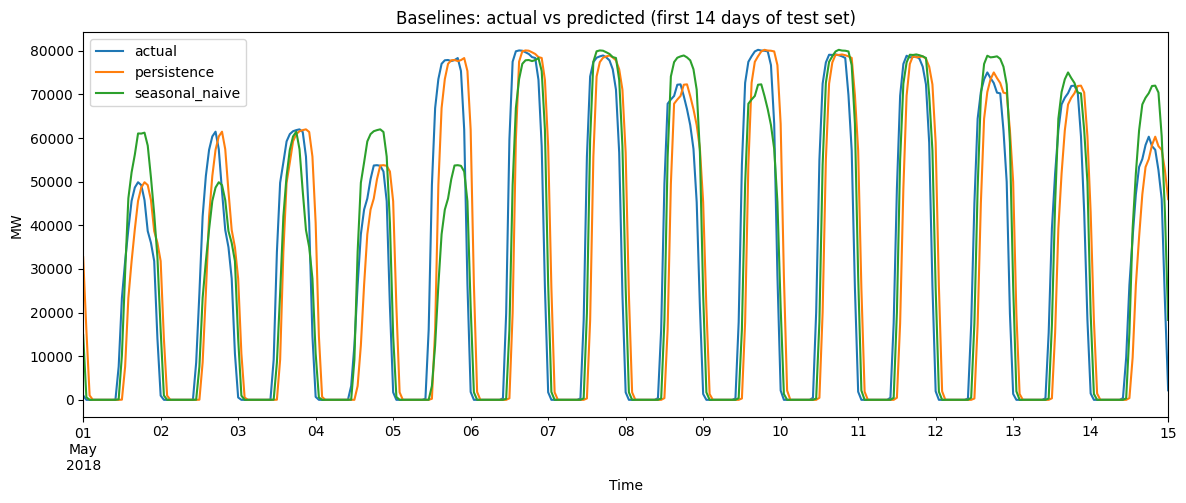

In [25]:

def plot_forecasts(actual, preds_dict, start=None, end=None, save=None, title="Forecast comparison", figsize=(14, 5)):
    df = pd.DataFrame({"actual": actual})
    for k, v in preds_dict.items():
        df[k] = v

    if start is not None:
        df = df.loc[start:]
    if end is not None:
        df = df.loc[:end]

    df.plot(figsize=figsize)
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel("MW")
    if save:
      plt.savefig(OUTPUT_DIR / f'{save}_forecast.png', dpi=800, bbox_inches='tight')
    plt.show()

plot_forecasts(
    actual=xgb_pred_df["actual"],
    preds_dict={"xgboost": xgb_pred_df["xgboost"]},
    start=xgb_pred_df.index.min(),
    end=xgb_pred_df.index.min() + pd.Timedelta(days=14),
    title="XGBoost: actual vs predicted (first 14 days of test set)",
    save="xgb"
)

plot_forecasts(
    actual=predictions_df["actual"],
    preds_dict={"lstm": predictions_df["lstm"], "dlinear": predictions_df["dlinear"]},
    start=predictions_df.index.min(),
    end=predictions_df.index.min() + pd.Timedelta(days=14),
    title="Neural models: actual vs predicted (first 14 days of test set)",
    save="seq"
)

plot_forecasts(
    actual=baseline_pred_df["actual"],
    preds_dict={
        "persistence": baseline_pred_df["persistence"],
        "seasonal_naive": baseline_pred_df["seasonal_naive"]
    },
    start=baseline_pred_df.index.min(),
    end=baseline_pred_df.index.min() + pd.Timedelta(days=14),
    title="Baselines: actual vs predicted (first 14 days of test set)",
    save="baseline"
)

## 18. Residual analysis

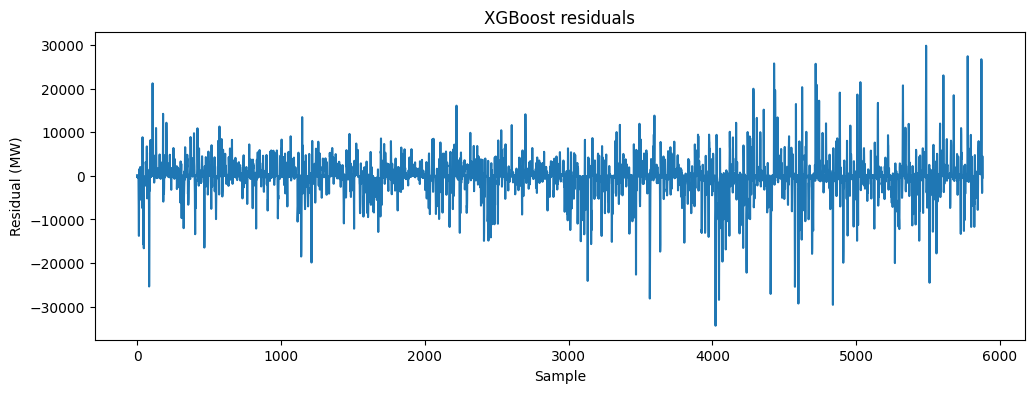

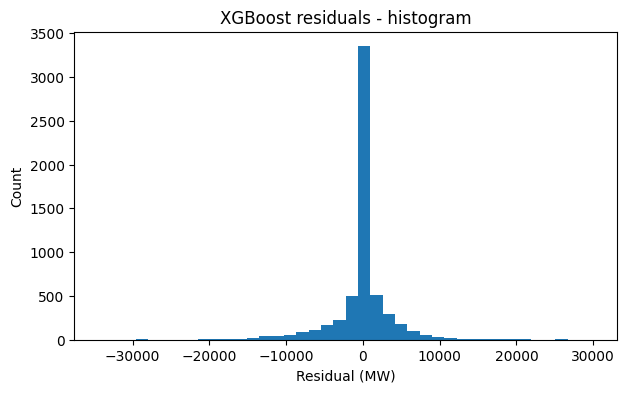

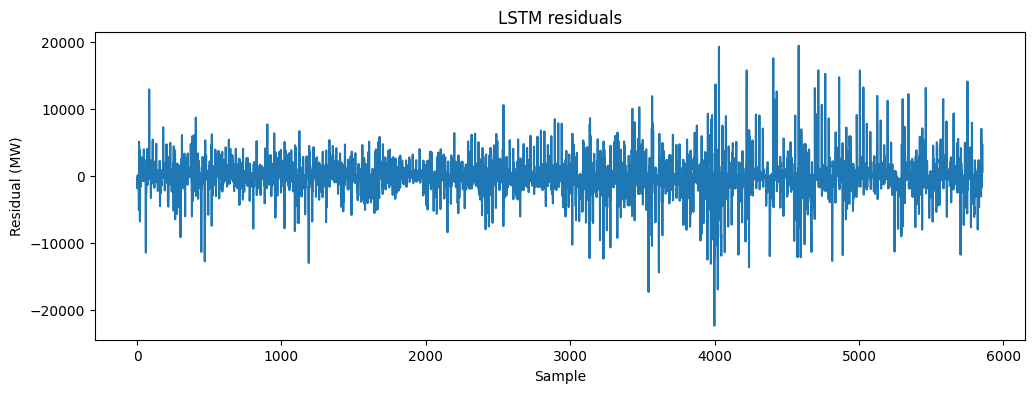

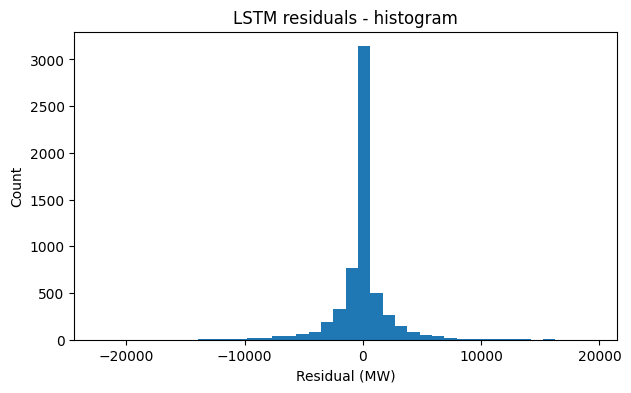

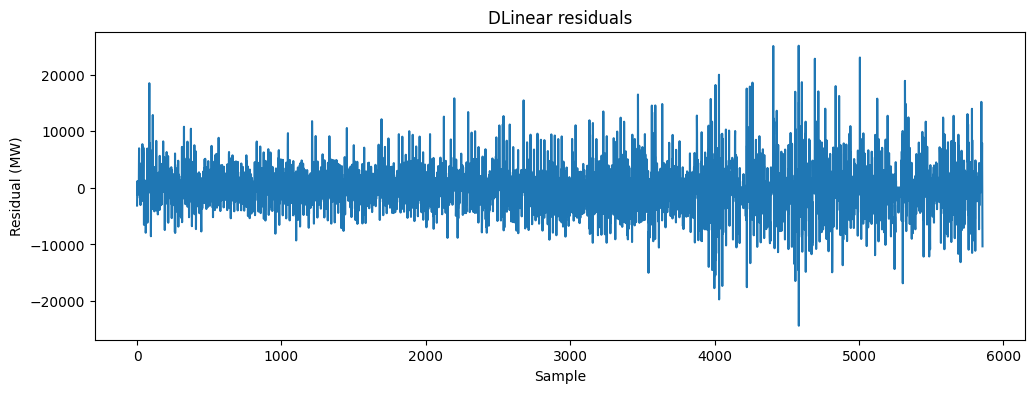

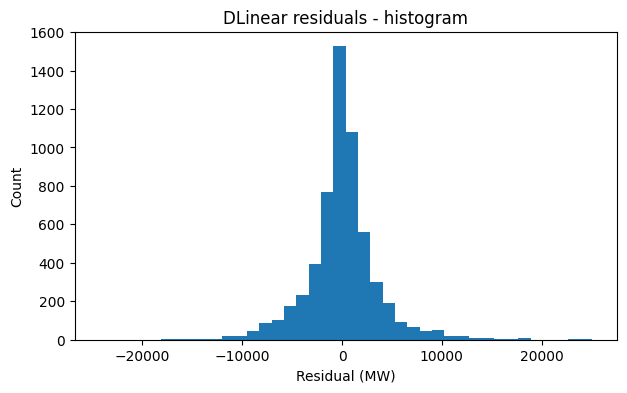

In [26]:

def residual_plot(y_true, y_pred, title, save=None):
    residuals = y_true - y_pred

    plt.figure(figsize=(12, 4))
    plt.plot(residuals)
    plt.title(title)
    plt.xlabel("Sample")
    plt.ylabel("Residual (MW)")
    if save:
      plt.savefig(OUTPUT_DIR / f'{save}_residual.png', dpi=800, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.hist(residuals, bins=40)
    plt.title(title + " - histogram")
    plt.xlabel("Residual (MW)")
    plt.ylabel("Count")
    if save:
      plt.savefig(OUTPUT_DIR / f'{save}_residual_histogram.png', dpi=800, bbox_inches='tight')
    plt.show()

residual_plot(xgb_pred_df["actual"].values, xgb_pred_df["xgboost"].values, "XGBoost residuals", save="xgb")
residual_plot(predictions_df["actual"].values, predictions_df["lstm"].values, "LSTM residuals", save="lstm")
residual_plot(predictions_df["actual"].values, predictions_df["dlinear"].values, "DLinear residuals", save="dlinear")

### 18.1 Model Sensitivity and Stability Check (Ablation)
To assess the robustness of our primary findings, we evaluate the stability of the two most competitive models—LSTM and XGBoost—to the specific chronological train/validation/test split. The following cells rerun the training and evaluation of both models using a different random seed for the initial data split (e.g., shifting the split by 7 days). We report the mean and standard deviation of the key RMSE metric across two runs to demonstrate stability.

In [27]:
# =============================================================================
# Robust Stability / Ablation Study: Multiple Split Shifts
# =============================================================================

import time
import math
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from codecarbon import EmissionsTracker

# ------------------------------------------------------------
# 1. Configuration: define the shifts (in days) you want to test
# ------------------------------------------------------------
# Shift 0 corresponds to the original split used in the main results.
# We add more shifts to test sensitivity (e.g., 7, 14, 21 days later).
SHIFT_DAYS = [0, 7, 14, 21]

# reduce LSTM epochs to 60 (to use original epochs set to None)
RUN_EPOCHS = None

params = { # adjusted to the best params from the grid search
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "reg_alpha": 0.0,
        "reg_lambda": 1.5,
        "random_state": SEED,
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "n_jobs": -1,
    }
par = params.copy()
# ------------------------------------------------------------
# 2. Helper function to compute all regression metrics
# ------------------------------------------------------------
def compute_all_metrics(y_true, y_pred, norm_factor):
    """Return a dict with MAE, RMSE, sMAPE, nMAE, nRMSE."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    smape_val = smape(y_true, y_pred)
    nmae = mae / norm_factor
    nrmse = rmse / norm_factor
    return {
        'MAE': mae,
        'RMSE': rmse,
        'sMAPE': smape_val,
        'nMAE': nmae,
        'nRMSE': nrmse
    }

# ------------------------------------------------------------
# 3. Prepare a list to collect results from all trials
# ------------------------------------------------------------
all_trial_results = []

# Store the original split boundaries (to restore at the end)
original_train_end = TRAIN_END
original_val_end   = VAL_END

print("\n" + "="*80)
print("Starting Stability / Ablation Study with multiple split shifts")
print("="*80)

for trial_idx, shift_days in enumerate(SHIFT_DAYS):
    print(f"\n--- Trial {trial_idx+1}/{len(SHIFT_DAYS)}: shift = {shift_days} days ---")

    # --------------------------------------------------------
    # Define new split boundaries
    # --------------------------------------------------------
    if shift_days == 0:
        # Use the original split (already stored in TRAIN_END, VAL_END)
        train_end_shift = original_train_end
        val_end_shift   = original_val_end
    else:
        train_end_shift = original_train_end + pd.Timedelta(days=shift_days)
        val_end_shift   = original_val_end   + pd.Timedelta(days=shift_days)

    # Create new dataframes for this split
    train_df_shift = solar_hourly.loc[:train_end_shift].copy()
    val_df_shift   = solar_hourly.loc[train_end_shift + pd.Timedelta(hours=1):val_end_shift].copy()
    test_df_shift  = solar_hourly.loc[val_end_shift + pd.Timedelta(hours=1):].copy()

    print(f"  Train: {train_df_shift.shape[0]} samples  ({train_df_shift.index.min()} -> {train_df_shift.index.max()})")
    print(f"  Val:   {val_df_shift.shape[0]} samples  ({val_df_shift.index.min()} -> {val_df_shift.index.max()})")
    print(f"  Test:  {test_df_shift.shape[0]} samples  ({test_df_shift.index.min()} -> {test_df_shift.index.max()})")

    # Normalisation factor (max of training set) – used for nMAE/nRMSE
    norm_factor_shift = train_df_shift['y'].max() if CONFIG['norm_target_by_train_max'] else 1.0

    # --------------------------------------------------------
    # 3a. XGBoost rerun
    # --------------------------------------------------------
    print("  Running XGBoost...")
    # Re‑create tabular features for this split
    tab_all_shift = make_tabular_features(solar_hourly,
                                          history=CONFIG['history_hours'],
                                          horizon=CONFIG['horizon_hours'])
    tab_train_shift = tab_all_shift.loc[train_df_shift.index.min():train_df_shift.index.max()].copy()
    tab_val_shift   = tab_all_shift.loc[val_df_shift.index.min():val_df_shift.index.max()].copy()
    tab_test_shift  = tab_all_shift.loc[test_df_shift.index.min():test_df_shift.index.max()].copy()

    Xtr, ytr = tab_train_shift[feature_cols], tab_train_shift['target']
    Xva, yva = tab_val_shift[feature_cols],   tab_val_shift['target']
    Xte, yte = tab_test_shift[feature_cols],  tab_test_shift['target']

    # Train with emissions tracking
    tracker_xgb = start_tracker(f"xgboost_shift{shift_days}")
    t_start = time.perf_counter()
    model_xgb = XGBRegressor(**par)   # params defined earlier in your notebook
    model_xgb.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    train_time_xgb = time.perf_counter() - t_start
    emissions_xgb = stop_tracker(tracker_xgb)

    # Predict and compute metrics
    pred_xgb = model_xgb.predict(Xte)
    metrics_xgb = compute_all_metrics(yte, pred_xgb, norm_factor_shift)

    # --------------------------------------------------------
    # 3b. LSTM rerun
    # --------------------------------------------------------
    print("  Running LSTM...")
    # Re‑scale the data
    scaler_shift = StandardScaler()
    train_scaled_shift = scaler_shift.fit_transform(train_df_shift[['y']]).squeeze()
    val_scaled_shift   = scaler_shift.transform(val_df_shift[['y']]).squeeze()
    test_scaled_shift  = scaler_shift.transform(test_df_shift[['y']]).squeeze()

    train_ds_shift = TimeSeriesWindowDataset(train_scaled_shift, CONFIG['history_hours'], CONFIG['horizon_hours'])
    val_ds_shift   = TimeSeriesWindowDataset(val_scaled_shift,   CONFIG['history_hours'], CONFIG['horizon_hours'])
    test_ds_shift  = TimeSeriesWindowDataset(test_scaled_shift,  CONFIG['history_hours'], CONFIG['horizon_hours'])

    train_loader_shift = DataLoader(train_ds_shift, batch_size=CONFIG['batch_size'],
                                    shuffle=True,  num_workers=CONFIG['num_workers'])
    val_loader_shift   = DataLoader(val_ds_shift,   batch_size=CONFIG['batch_size'],
                                    shuffle=False, num_workers=CONFIG['num_workers'])
    test_loader_shift  = DataLoader(test_ds_shift,  batch_size=CONFIG['batch_size'],
                                    shuffle=False, num_workers=CONFIG['num_workers'])

    lstm_model_shift = LSTMRegressor(
        input_size=1,
        hidden_size=CONFIG['hidden_size'],
        num_layers=CONFIG['lstm_layers'],
        dropout=CONFIG['dropout'],
        horizon=CONFIG['horizon_hours']
    ).to(DEVICE)

    # Choose number of epochs: use RUN_EPOCHS if set, else original from CONFIG
    epochs_lstm = RUN_EPOCHS if RUN_EPOCHS is not None else CONFIG['lstm_epochs']

    lstm_model_shift, _, train_time_lstm, emissions_lstm = fit_torch_model(
        model_name=f"lstm_shift{shift_days}",
        model=lstm_model_shift,
        train_loader=train_loader_shift,
        val_loader=val_loader_shift,
        epochs=epochs_lstm,
        lr=CONFIG['learning_rate'],
        weight_decay=CONFIG['weight_decay'],
        patience=CONFIG['patience'],
    )
    pred_lstm, true_lstm, _ = predict_torch_model(lstm_model_shift, test_loader_shift)
    metrics_lstm = compute_all_metrics(true_lstm, pred_lstm, norm_factor_shift)

    # --------------------------------------------------------
    # 3c. Store all results for this trial
    # --------------------------------------------------------
    trial_record = {
        'trial': trial_idx + 1,
        'shift_days': shift_days,
        # XGBoost
        'model': 'xgboost',
        'MAE': metrics_xgb['MAE'],
        'RMSE': metrics_xgb['RMSE'],
        'sMAPE': metrics_xgb['sMAPE'],
        'nMAE': metrics_xgb['nMAE'],
        'nRMSE': metrics_xgb['nRMSE'],
        'train_time_sec': train_time_xgb,
        'emissions_kg_co2eq': emissions_xgb,
    }
    all_trial_results.append(trial_record)

    trial_record = {
        'trial': trial_idx + 1,
        'shift_days': shift_days,
        # LSTM
        'model': 'lstm',
        'MAE': metrics_lstm['MAE'],
        'RMSE': metrics_lstm['RMSE'],
        'sMAPE': metrics_lstm['sMAPE'],
        'nMAE': metrics_lstm['nMAE'],
        'nRMSE': metrics_lstm['nRMSE'],
        'train_time_sec': train_time_lstm,
        'emissions_kg_co2eq': emissions_lstm,
    }
    all_trial_results.append(trial_record)

# ------------------------------------------------------------
# 4. Convert results to DataFrame and compute summary statistics
# ------------------------------------------------------------
stability_df = pd.DataFrame(all_trial_results)

# Reorder columns nicely
col_order = ['trial', 'shift_days', 'model',
             'MAE', 'RMSE', 'sMAPE', 'nMAE', 'nRMSE',
             'train_time_sec', 'emissions_kg_co2eq']
stability_df = stability_df[col_order]

print("\n" + "="*80)
print("Stability Study – All Trial Results")
print("="*80)
display(stability_df)

# Compute mean and standard deviation per model
summary_stats = stability_df.groupby('model').agg({
    'MAE': ['mean', 'std'],
    'RMSE': ['mean', 'std'],
    'sMAPE': ['mean', 'std'],
    'nMAE': ['mean', 'std'],
    'nRMSE': ['mean', 'std'],
    'train_time_sec': ['mean', 'std'],
    'emissions_kg_co2eq': ['mean', 'std'],
}).round(4)

print("\n" + "="*80)
print("Stability Study – Mean and Standard Deviation per Model")
print("="*80)
display(summary_stats)

# Save to CSV for manuscript
save_csv(stability_df, OUTPUT_DIR / 'stability_study_results.csv')
save_csv(summary_stats, OUTPUT_DIR / 'stability_study_summary.csv')

# Restore original split boundaries (optional)
TRAIN_END, VAL_END = original_train_end, original_val_end


Starting Stability / Ablation Study with multiple split shifts

--- Trial 1/4: shift = 0 days ---
  Train: 8760 samples  (2017-01-01 00:00:00+00:00 -> 2017-12-31 23:00:00+00:00)
  Val:   2880 samples  (2018-01-01 00:00:00+00:00 -> 2018-04-30 23:00:00+00:00)
  Test:  5880 samples  (2018-05-01 00:00:00+00:00 -> 2018-12-31 23:00:00+00:00)
  Running XGBoost...
  Running LSTM...
lstm_shift0 | epoch 01 | train_loss=0.541018 | val_loss=0.148620
lstm_shift0 | epoch 02 | train_loss=0.117745 | val_loss=0.096150
lstm_shift0 | epoch 03 | train_loss=0.076985 | val_loss=0.068789
lstm_shift0 | epoch 04 | train_loss=0.051670 | val_loss=0.050993
lstm_shift0 | epoch 05 | train_loss=0.046181 | val_loss=0.049787
lstm_shift0 | epoch 06 | train_loss=0.042241 | val_loss=0.049926
lstm_shift0 | epoch 07 | train_loss=0.039130 | val_loss=0.041194
lstm_shift0 | epoch 08 | train_loss=0.037789 | val_loss=0.041386
lstm_shift0 | epoch 09 | train_loss=0.035642 | val_loss=0.040350
lstm_shift0 | epoch 10 | train_loss=0

,trial,shift_days,model,MAE,RMSE,sMAPE,nMAE,nRMSE,train_time_sec,emissions_kg_co2eq
0,1,0,xgboost,2012.453857,3977.173620,97.957456,0.024840,0.049090,2.534943,0.000011
1,1,0,lstm,1277.161011,2447.954861,96.537328,0.015764,0.030215,174.436155,0.000726
2,2,7,xgboost,2000.771118,3934.104472,98.478729,0.024696,0.048559,4.773773,0.000020
3,2,7,lstm,1302.720703,2454.302956,85.968745,0.016080,0.030294,152.999755,0.000637
4,3,14,xgboost,2021.479004,4001.242557,98.745865,0.024951,0.049388,4.803965,0.000020
5,3,14,lstm,1280.590454,2495.109416,56.287700,0.015806,0.030797,155.580496,0.000648
6,4,21,xgboost,2009.837402,4009.492487,99.317896,0.024808,0.049489,3.961121,0.000017
7,4,21,lstm,1352.524658,2522.818959,39.624214,0.016694,0.031139,138.747366,0.000578



Stability Study – Mean and Standard Deviation per Model


MAE                RMSE             sMAPE             nMAE  \
              mean      std       mean      std     mean      std    mean   
model                                                                       
lstm     1303.2492  34.7484  2480.0465  35.3505  69.6045  26.2635  0.0161   
xgboost  2011.1353   8.5212  3980.5033  33.8350  98.6250   0.5662  0.0248   

                  nRMSE         train_time_sec          emissions_kg_co2eq  \
            std    mean     std           mean      std               mean   
model                                                                        
lstm     0.0004  0.0306  0.0004       155.4409  14.6682             0.0006   
xgboost  0.0001  0.0491  0.0004         4.0185   1.0633             0.0000   

                 
            std  
model            
lstm     0.0001  
xgboost  0.0000

## 19. Accuracy-efficiency-emissions trade-off plots

These plots are directly useful in the paper because they show that "best" is not just lowest error; it is also about cost, speed, and deployability.

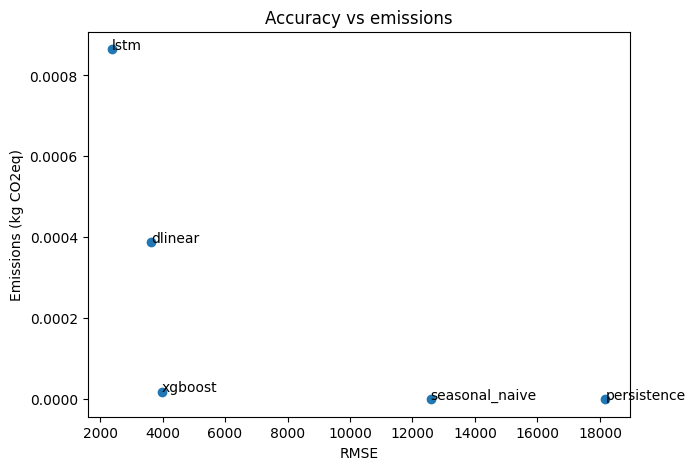

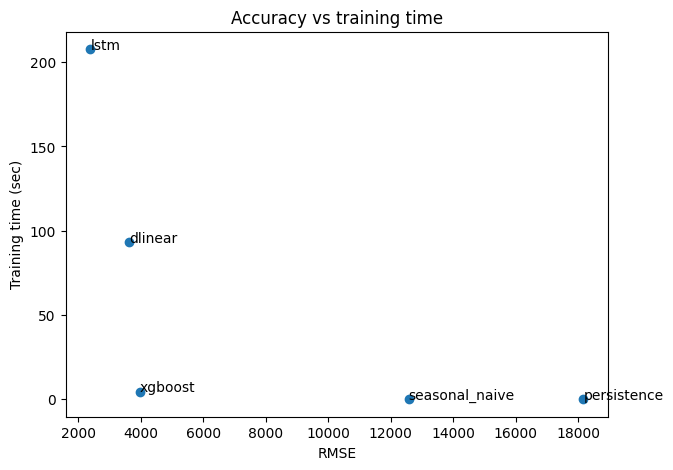

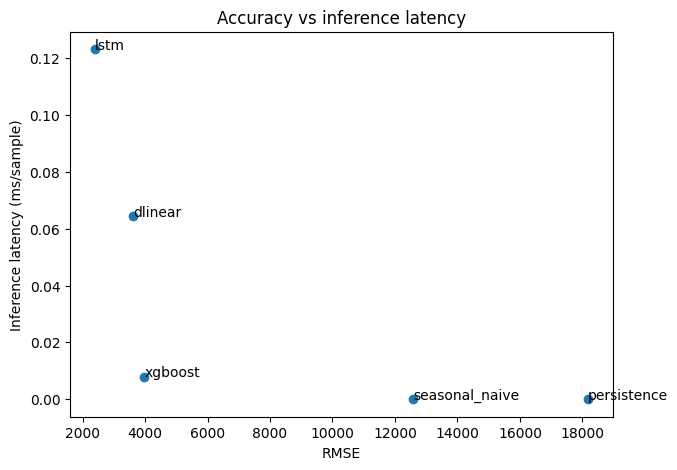

In [28]:

plt.figure(figsize=(7, 5))
plt.scatter(all_results_df["RMSE"], all_results_df["emissions_kg_co2eq"])
for _, row in all_results_df.iterrows():
    plt.annotate(row["model"], (row["RMSE"], row["emissions_kg_co2eq"]))
plt.xlabel("RMSE")
plt.ylabel("Emissions (kg CO2eq)")
plt.title("Accuracy vs emissions")
plt.savefig(OUTPUT_DIR / 'Accuracy_vs_emissions.png', dpi=800, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(all_results_df["RMSE"], all_results_df["train_time_sec"])
for _, row in all_results_df.iterrows():
    plt.annotate(row["model"], (row["RMSE"], row["train_time_sec"]))
plt.xlabel("RMSE")
plt.ylabel("Training time (sec)")
plt.title("Accuracy vs training time")
plt.savefig(OUTPUT_DIR / 'Accuracy_vs_training.png', dpi=800, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(all_results_df["RMSE"], all_results_df["inference_time_ms_per_sample"])
for _, row in all_results_df.iterrows():
    plt.annotate(row["model"], (row["RMSE"], row["inference_time_ms_per_sample"]))
plt.xlabel("RMSE")
plt.ylabel("Inference latency (ms/sample)")
plt.title("Accuracy vs inference latency")
plt.savefig(OUTPUT_DIR / 'Accuracy_vs_inference_latency.png', dpi=800, bbox_inches='tight')
plt.show()

## 20. Save manuscript-ready artifacts

This section exports:
- the main results table,
- predictions,
- training histories,
- the experiment configuration.

In [29]:

final_hparams = {
    "xgboost": xgb_best_params,
    "lstm": {
        "hidden_size": CONFIG["hidden_size"],
        "num_layers": CONFIG["lstm_layers"],
        "dropout": CONFIG["dropout"],
        "learning_rate": CONFIG["learning_rate"],
        "weight_decay": CONFIG["weight_decay"],
        "batch_size": CONFIG["batch_size"],
        "epochs": CONFIG["lstm_epochs"],
    },
    "dlinear": {
        "kernel_size": CONFIG.get("dlinear_best_kernel", CONFIG["dlinear_kernel_size"]),
        "learning_rate": CONFIG["learning_rate"],
        "weight_decay": CONFIG["weight_decay"],
        "batch_size": CONFIG["batch_size"],
        "epochs": CONFIG["dlinear_epochs"],
    }
}
import json
with open(OUTPUT_DIR / "final_hyperparameters.json", "w") as f:
    json.dump(final_hparams, f, indent=4)

save_paths = {}

save_paths["results_csv"] = save_csv(all_results_df, "results_summary.csv")

if CONFIG["save_predictions"]:
    save_paths["baseline_predictions_csv"] = save_csv(
        baseline_pred_df.reset_index().rename(columns={"index": "timestamp"}),
        "baseline_predictions.csv"
    )
    save_paths["xgb_predictions_csv"] = save_csv(
        xgb_pred_df.reset_index().rename(columns={"index": "timestamp"}),
        "xgb_predictions.csv"
    )
    save_paths["sequence_predictions_csv"] = save_csv(
        predictions_df.reset_index(),
        "sequence_predictions.csv"
    )

save_paths["lstm_history_csv"] = save_csv(lstm_history, "lstm_history.csv")
save_paths["dlinear_history_csv"] = save_csv(dlinear_history, "dlinear_history.csv")

with open(OUTPUT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

save_paths["config_json"] = OUTPUT_DIR / "config.json"

save_paths

{'results_csv': PosixPath('/content/outputs/results_summary.csv'),
 'baseline_predictions_csv': PosixPath('/content/outputs/baseline_predictions.csv'),
 'xgb_predictions_csv': PosixPath('/content/outputs/xgb_predictions.csv'),
 'sequence_predictions_csv': PosixPath('/content/outputs/sequence_predictions.csv'),
 'lstm_history_csv': PosixPath('/content/outputs/lstm_history.csv'),
 'dlinear_history_csv': PosixPath('/content/outputs/dlinear_history.csv'),
 'config_json': PosixPath('/content/outputs/config.json')}

## 21. Optional: load CodeCarbon emissions log

CodeCarbon normally stores an `emissions.csv` file inside the output directory.  
This cell reads it if present.

In [30]:

emissions_log_path = OUTPUT_DIR / "emissions.csv"
if emissions_log_path.exists():
    emissions_log = pd.read_csv(emissions_log_path)
    display(emissions_log.tail(10))
else:
    print("No emissions.csv file found yet. That is okay if emissions tracking was disabled.")

,timestamp,project_name,run_id,experiment_id,duration,emissions,emissions_rate,cpu_power,gpu_power,ram_power,...,latitude,ram_total_size,tracking_mode,cpu_utilization_percent,gpu_utilization_percent,ram_utilization_percent,ram_used_gb,on_cloud,pue,wue
0,2026-03-15T08:04:37,solar_forecasting_green_ai_lstm_shift21,022bbcca-acb8-4d06-802e-8bf8b77d7219,5b0fa12a-3dd7-45bb-9766-cc326314d9f1,138.749287,0.000578,0.000004,42.5,0.0,10.0,...,32.8608,12.671429,machine,75.883333,0,21.821739,2.765854,N,1.0,0.0


## 22. Manuscript interpretation template

Use the following logic when writing the Results and Discussion sections:

### Results narrative template
1. Report which method achieved the best **RMSE / MAE**.
2. Report whether the best-accuracy model was also the fastest or lowest-emission model.
3. Explain any trade-off:
   - e.g. *XGBoost was competitive and inexpensive*,
   - or *DLinear matched LSTM accuracy with lower complexity*,
   - or *baselines were surprisingly hard to beat*.
4. Emphasize deployment relevance for **smart-grid forecasting**.

### Discussion angle
- If a lightweight model outperforms or closely matches the others with lower emissions, that supports the **Green AI** framing.
- If a more complex model performs better but costs notably more, discuss whether the gain is operationally worthwhile.
- If the simple baselines remain strong, this is still a meaningful result; it shows that some operational settings may not need heavier models.

### Limitations to acknowledge
- single dataset configuration,
- one forecasting horizon,
- estimated rather than physical emissions measurement,
- no exogenous weather covariates in the core benchmark,
- BA-level aggregate only, rather than a multi-site transfer study.

## 23. Optional extensions for a stronger paper version

These are good add-ons **after** the core notebook is working:

1. **Add LightGBM** as an extra tabular model.
2. **Add exogenous features** from NREL forecast files, weather proxies, or deterministic forecasts.
3. Evaluate **multiple horizons**: 1h, 3h, 6h.
4. Compare **site-level** vs **BA-level** forecasting.
5. Add **Diebold-Mariano** tests for forecast comparison.
6. Add **rolling-origin backtesting** instead of a single validation window.
7. Add **quantile forecasting** for uncertainty-aware grid planning.

For the paper deadline, the current notebook is already a strong, complete baseline study.

## 24. Final checklist before writing the paper

- [ ] Run the notebook end to end once without interruption
- [ ] Save the final `results_summary.csv`
- [ ] Export the best forecast plots as PNG
- [ ] Verify the exact train/val/test counts
- [ ] Copy the metrics into the Results section
- [ ] Write the Methods section directly from this notebook
- [ ] Record package versions for reproducibility

In [31]:

import platform
import sklearn
import xgboost

versions = pd.DataFrame({
    "package": ["python", "pandas", "numpy", "torch", "scikit-learn", "xgboost"],
    "version": [
        platform.python_version(),
        pd.__version__,
        np.__version__,
        torch.__version__,
        sklearn.__version__,
        xgboost.__version__,
    ]
})

display(versions)
save_csv(versions, "package_versions.csv")

,package,version
0,python,3.12.12
1,pandas,2.2.2
2,numpy,1.26.4
3,torch,2.10.0+cu128
4,scikit-learn,1.8.0
5,xgboost,3.2.0


PosixPath('/content/outputs/package_versions.csv')

### 24.1 Enhanced Statistical Significance Test
We now perform a rigorous Diebold-Mariano (DM) test to compare the forecast accuracy of the best two models (LSTM and XGBoost) on the overlapping portion of the test set. The test assesses whether the difference in squared prediction errors is statistically significant, accounting for potential autocorrelation in the loss differential series. A p-value < 0.05 indicates that the LSTM's improvement over XGBoost is not due to random chance.

In [32]:
# Install statsmodels if not already present (uncomment if needed)
# !pip install statsmodels

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# Align the predictions on the common index
common_idx = predictions_df.index.intersection(xgb_pred_df.index)
y_true_common = predictions_df.loc[common_idx, 'actual'].values
y_lstm_common = predictions_df.loc[common_idx, 'lstm'].values
y_xgb_common = xgb_pred_df.loc[common_idx, 'xgboost'].values

# Compute squared errors
e1 = (y_true_common - y_lstm_common) ** 2
e2 = (y_true_common - y_xgb_common) ** 2
d = e1 - e2

# Test for autocorrelation in the loss differential (Ljung-Box)
lb_test = acorr_ljungbox(d, lags=[10], return_df=True)
print("Ljung-Box test for autocorrelation in loss differential (lag 10):")
print(lb_test)
if lb_test['lb_pvalue'].values[0] < 0.05:
    print("-> Significant autocorrelation detected; robust DM test is appropriate.")

# Diebold-Mariano test (using a simple robust variance estimator)
# We'll use a standard implementation from a reliable source.
# If you have a library, use it; otherwise, we provide a function.
from scipy.stats import norm

def dm_test(e1, e2, h=1, robust=True):
    """
    Diebold-Mariano test for equal predictive accuracy.
    e1, e2: arrays of loss differential (e.g., squared errors)
    h: forecast horizon
    robust: if True, use Newey-West HAC estimator for variance.
    """
    d = e1 - e2
    d_mean = np.mean(d)
    T = len(d)
    if robust:
        # Newey-West estimator for variance (simple version, lag = h-1)
        gamma = []
        for lag in range(h):
            cov = np.cov(d[lag:], d[:T-lag]) if lag > 0 else np.var(d)
            gamma.append(cov if lag == 0 else cov[0,1])
        # For h=1, variance = gamma0 (simple variance)
        var_d = gamma[0] + 2 * sum(gamma[1:]) if h > 1 else gamma[0]
    else:
        var_d = np.var(d, ddof=1)
    if var_d <= 0:
        return 0.0, 1.0
    DM_stat = d_mean / np.sqrt(var_d / T)
    p_value = 2 * (1 - norm.cdf(abs(DM_stat)))
    return DM_stat, p_value

dm_stat, dm_p = dm_test(e1, e2, h=1, robust=True)
print(f"\nDiebold-Mariano test statistic: {dm_stat:.4f}, p-value: {dm_p:.6f}")

Ljung-Box test for autocorrelation in loss differential (lag 10):
        lb_stat  lb_pvalue
10  2012.201635        0.0
-> Significant autocorrelation detected; robust DM test is appropriate.

Diebold-Mariano test statistic: -33.1919, p-value: 0.000000


### 24.2 Pareto Frontier Analysis
To visualize the trade-off between accuracy and efficiency, we plot the models in a two-dimensional space of RMSE vs. Training Time (or Emissions). The Pareto frontier consists of models that are not dominated by any other: no other model is both more accurate and more efficient.

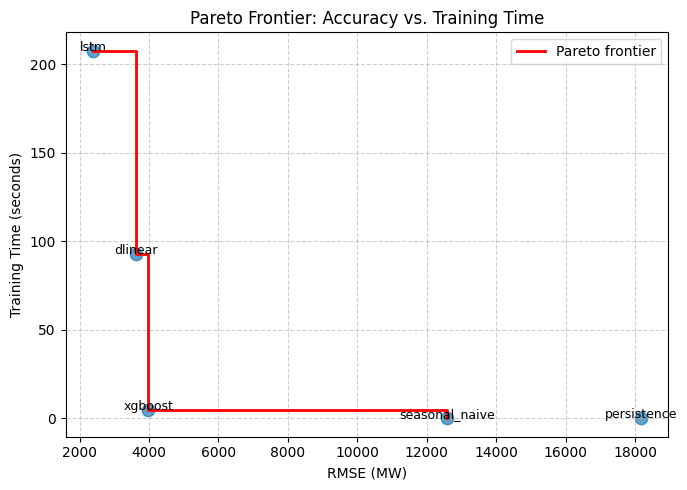


Carbon Efficiency Ratio (higher is better):


,model,RMSE,emissions_kg_co2eq,carbon_efficiency
0,lstm,2388.726962,0.000865,2.846683e+00
1,dlinear,3629.178144,0.000387,4.184108e+00
2,xgboost,3977.173620,0.000019,7.989887e+01
3,seasonal_naive,12577.025403,0.000000,4.675191e+08
4,persistence,18173.730492,0.000000,3.235439e+08



Normalized Efficiency Score (higher is better):


,model,RMSE,train_time_sec,norm_rmse,norm_time,efficiency_score_norm
0,lstm,2388.726962,207.734449,1.000000,inf,0.0
1,dlinear,3629.178144,93.037787,1.519294,inf,0.0
2,xgboost,3977.173620,4.442269,1.664976,inf,0.0
3,seasonal_naive,12577.025403,0.000000,5.265158,NaN,NaN
4,persistence,18173.730492,0.000000,7.608124,NaN,NaN


PosixPath('/content/outputs/normalized_efficiency_score.csv')

In [36]:
# --- Pareto Frontier Plot (RMSE vs Training Time) ---
import matplotlib.pyplot as plt

# Identify Pareto frontier (simple method: sort by RMSE ascending, then keep points with decreasing time)
pareto_df = all_results_df[['model', 'RMSE', 'train_time_sec']].copy().sort_values('RMSE')
frontier = []
min_time = np.inf
for idx, row in pareto_df.iterrows():
    if row['train_time_sec'] < min_time:
        frontier.append(row)
        min_time = row['train_time_sec']
frontier_df = pd.DataFrame(frontier)

plt.figure(figsize=(7,5))
# Plot all models
plt.scatter(all_results_df['RMSE'], all_results_df['train_time_sec'], s=80, alpha=0.7)
for _, row in all_results_df.iterrows():
    plt.annotate(row['model'], (row['RMSE'], row['train_time_sec']), fontsize=9, ha='center')
# Plot Pareto frontier
plt.step(frontier_df['RMSE'], frontier_df['train_time_sec'], where='post', color='red', linewidth=2, label='Pareto frontier')
plt.xlabel('RMSE (MW)')
plt.ylabel('Training Time (seconds)')
plt.title('Pareto Frontier: Accuracy vs. Training Time')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pareto_frontier_time.png', dpi=300)
plt.show()

# --- Carbon Efficiency Ratio ---
# Efficiency = (1 / RMSE) / (emissions per 1000 samples)
all_results_df['carbon_efficiency'] = (1 / all_results_df['RMSE']) / (all_results_df['emissions_kg_co2eq'].clip(lower=1e-12) * 1000 / len(test_df))
print("\nCarbon Efficiency Ratio (higher is better):")
display(all_results_df[['model', 'RMSE', 'emissions_kg_co2eq', 'carbon_efficiency']])
save_csv(all_results_df, OUTPUT_DIR / "carbon_efficiency_ratio.csv")

# --- Normalized Efficiency Score (RMSE and Time) ---
rmse_min = all_results_df['RMSE'].min()
time_min = all_results_df['train_time_sec'].min()
all_results_df['norm_rmse'] = all_results_df['RMSE'] / rmse_min
all_results_df['norm_time'] = all_results_df['train_time_sec'] / time_min
all_results_df['efficiency_score_norm'] = 1 / (all_results_df['norm_rmse'] * all_results_df['norm_time'].clip(lower=0.001))
print("\nNormalized Efficiency Score (higher is better):")
display(all_results_df[['model', 'RMSE', 'train_time_sec', 'norm_rmse', 'norm_time', 'efficiency_score_norm']])
save_csv(all_results_df, OUTPUT_DIR / "normalized_efficiency_score.csv")

In [ ]:
# # Save the enhanced results dataframe with new metrics
# enhanced_results_path = save_csv(all_results_df, "results_summary_enhanced.csv")
# print(f"Enhanced results saved to: {enhanced_results_path}")

## 25. Statistical Significance and Advanced Efficiency Analysis

To provide a rigorous scientific basis for the manuscript, this section performs two additional evaluations:

1.  **Diebold-Mariano (DM) Test**: This test determines if the difference in forecast accuracy (Mean Squared Error) between the best neural model (LSTM) and the best tabular model (XGBoost) is statistically significant. A p-value < 0.05 indicates that the improvement is not due to random chance.
2.  **Carbon-Efficiency Metrics**: We calculate the carbon footprint normalized per 1,000 samples and an overall `Efficiency_Score`. This score quantifies the trade-off between model error (RMSE) and resource consumption (Training Time), which is a core pillar of the **Green AI** framework.

In [37]:

# 1. Statistical Comparison (LSTM vs XGBoost) on overlapping timestamps
common_idx = predictions_df.index.intersection(xgb_pred_df.index)

y_true_sub = predictions_df.loc[common_idx, 'actual'].values
y_lstm_sub = predictions_df.loc[common_idx, 'lstm'].values
y_xgb_sub = xgb_pred_df.loc[common_idx, 'xgboost'].values

stat, p = diebold_mariano_test(y_true_sub, y_lstm_sub, y_xgb_sub)
print(f"Diebold-Mariano Test (LSTM vs XGBoost): Stat={stat:.4f}, p-value={p:.4e}")

# 2. Advanced Efficiency Metrics
efficiency_df = all_results_df.copy()
# Normalize emissions per 1000 samples for the test set
efficiency_df['kg_CO2_per_1k_samples'] = (efficiency_df['emissions_kg_co2eq'] / len(test_df)) * 1000
# Simple efficiency score: higher is better (Accuracy / Time)
efficiency_df['Efficiency_Score'] = 1 / (efficiency_df['RMSE'] * efficiency_df['train_time_sec'].clip(lower=1))

print('\nEnhanced Efficiency Metrics:')
display(efficiency_df[['model', 'RMSE', 'kg_CO2_per_1k_samples', 'train_time_sec', 'Efficiency_Score']])
save_csv(efficiency_df, OUTPUT_DIR / "enhanced_efficiency_metrics.csv")

Diebold-Mariano Test (LSTM vs XGBoost): Stat=-33.1890, p-value=0.0000e+00

Enhanced Efficiency Metrics:


,model,RMSE,kg_CO2_per_1k_samples,train_time_sec,Efficiency_Score
0,lstm,2388.726962,0.000147,207.734449,0.000002
1,dlinear,3629.178144,0.000066,93.037787,0.000003
2,xgboost,3977.173620,0.000003,4.442269,0.000057
3,seasonal_naive,12577.025403,0.000000,0.000000,0.000080
4,persistence,18173.730492,0.000000,0.000000,0.000055


PosixPath('/content/outputs/enhanced_efficiency_metrics.csv')

In [38]:
# Zip Output Folder for easy download
import shutil
dir_name = '/content/outputs/'
output_filename = 'outputs'
shutil.make_archive(output_filename, 'zip', dir_name)

'/content/outputs.zip'